In [1]:
import pandas as pd
from pathlib import Path

# Load the requested CSV files from the workspace directory
base_dir = Path.cwd()

files = {
    "assessments": "assessments.csv",
    "courses": "courses.csv",
    "studentinfo": "studentInfo.csv",
    "studentregistration": "studentRegistration.csv",
    "vle": "vle.csv",
    "studentvle": "studentVle.csv",
    "studentassessment": "studentAssessment.csv",
}

for name, filename in files.items():
    path = base_dir / filename
    if not path.exists():
        raise FileNotFoundError(f"{filename} not found at {path}")
    globals()[name] = pd.read_csv(path)
    print(f"{name}: {globals()[name].shape[0]} rows × {globals()[name].shape[1]} columns")

# Load cleaned datasets saved in Documents/cleaned_datasets
clean_dir = Path('/Users/perecharlaprasad/Documents/cleaned_datasets')
clean_files = {
    'assessments': 'cleaned_assessments.csv',
    'courses': 'cleaned_courses.csv',
    'studentinfo': 'cleaned_studentInfo.csv',
    'studentregistration': 'cleaned_studentRegistration.csv',
    'vle': 'cleaned_vle.csv',
    'studentvle': 'cleaned_studentVle.csv',
    'studentassessment': 'cleaned_studentAssessment.csv',
}

for name, fname in clean_files.items():
    path = clean_dir / fname
    if not path.exists():
        print(f"Warning: cleaned file not found: {path}")
        continue
    globals()[f'clean_{name}'] = pd.read_csv(path)
    df = globals()[f'clean_{name}']
    print(f"clean_{name}: {df.shape[0]} rows × {df.shape[1]} columns")

clean_df_names = [f'clean_{n}' for n in clean_files.keys()]


assessments: 206 rows × 6 columns
courses: 22 rows × 3 columns
studentinfo: 32593 rows × 12 columns
studentregistration: 32593 rows × 5 columns
vle: 6364 rows × 6 columns
studentvle: 195585 rows × 6 columns
studentassessment: 173912 rows × 5 columns
clean_assessments: 206 rows × 6 columns
clean_courses: 22 rows × 3 columns
clean_studentinfo: 32593 rows × 12 columns
clean_studentregistration: 32593 rows × 5 columns
clean_vle: 6364 rows × 6 columns
clean_studentvle: 187715 rows × 6 columns
clean_studentassessment: 173912 rows × 5 columns


In [2]:
df_names = ["assessments", "courses", "studentinfo", "studentregistration", "vle", "studentvle", "studentassessment"]

for name in df_names:
    df = globals()[name]
    print(f"\n{'=' * 80}")
    print(f"{name.upper()}" )
    print(f"{'=' * 80}")
    print("Shape:", df.shape)
    print("\nInfo:")
    df.info(verbose=False)
    print("\nMissing values:")
    print(df.isna().sum())
    print("\nDuplicate rows:", df.duplicated().sum())



ASSESSMENTS
Shape: (206, 6)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206 entries, 0 to 205
Columns: 6 entries, code_module to weight
dtypes: float64(2), int64(1), object(3)
memory usage: 9.8+ KB

Missing values:
code_module           0
code_presentation     0
id_assessment         0
assessment_type       0
date                 11
weight                0
dtype: int64

Duplicate rows: 0

COURSES
Shape: (22, 3)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Columns: 3 entries, code_module to module_presentation_length
dtypes: int64(1), object(2)
memory usage: 656.0+ bytes

Missing values:
code_module                   0
code_presentation             0
module_presentation_length    0
dtype: int64

Duplicate rows: 0

STUDENTINFO
Shape: (32593, 12)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Columns: 12 entries, code_module to final_result
dtypes: int64(3), object(9)
memory usage: 3.0+ MB

Missing values:
c

In [3]:
summary = []
for name in df_names:
    df = globals()[name]
    summary.append({
        "DataFrame": name,
        "Shape": df.shape,
        "Columns": list(df.columns),
        "Missing Values": int(df.isna().sum().sum()),
        "Missing by Column": df.isna().sum().to_dict(),
        "Duplicate Rows": int(df.duplicated().sum()),
        "Dtypes": df.dtypes.astype(str).to_dict(),
    })

for item in summary:
    print(f"\n{item['DataFrame']}")
    print("- Shape:", item["Shape"])
    print("- Columns:", item["Columns"])
    print("- Missing values total:", item["Missing Values"])
    print("- Duplicate rows:", item["Duplicate Rows"])
    print("- Dtypes:", item["Dtypes"])



assessments
- Shape: (206, 6)
- Columns: ['code_module', 'code_presentation', 'id_assessment', 'assessment_type', 'date', 'weight']
- Missing values total: 11
- Duplicate rows: 0
- Dtypes: {'code_module': 'object', 'code_presentation': 'object', 'id_assessment': 'int64', 'assessment_type': 'object', 'date': 'float64', 'weight': 'float64'}

courses
- Shape: (22, 3)
- Columns: ['code_module', 'code_presentation', 'module_presentation_length']
- Missing values total: 0
- Duplicate rows: 0
- Dtypes: {'code_module': 'object', 'code_presentation': 'object', 'module_presentation_length': 'int64'}

studentinfo
- Shape: (32593, 12)
- Columns: ['code_module', 'code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result']
- Missing values total: 1111
- Duplicate rows: 0
- Dtypes: {'code_module': 'object', 'code_presentation': 'object', 'id_student': 'int64', 'gender': 'object', 'region':

In [4]:
# Clean the studentvle dataframe by removing exact duplicates and handling missing values
studentvle_original = studentvle.copy()

print("Shape before cleaning:", studentvle_original.shape)
print("Duplicate rows before cleaning:", int(studentvle_original.duplicated().sum()))
print("Missing values before cleaning:")
print(studentvle_original.isna().sum())

# Remove exact duplicate rows
studentvle = studentvle_original.drop_duplicates().copy()

# Drop rows missing essential identifiers; fill click counts with 0 where missing
studentvle = studentvle.dropna(subset=["id_student", "id_site", "date"]).copy()
studentvle["sum_click"] = studentvle["sum_click"].fillna(0)

print("\nShape after cleaning:", studentvle.shape)
print("Duplicate rows after cleaning:", int(studentvle.duplicated().sum()))
print("Missing values after cleaning:")
print(studentvle.isna().sum())


Shape before cleaning: (195585, 6)
Duplicate rows before cleaning: 7869
Missing values before cleaning:
code_module          0
code_presentation    0
id_student           1
id_site              1
date                 1
sum_click            1
dtype: int64

Shape after cleaning: (187715, 6)
Duplicate rows after cleaning: 0
Missing values after cleaning:
code_module          0
code_presentation    0
id_student           0
id_site              0
date                 0
sum_click            0
dtype: int64


In [5]:
clean_names = [
    'clean_assessments', 'clean_courses', 'clean_studentinfo',
    'clean_studentregistration', 'clean_vle', 'clean_studentvle', 'clean_studentassessment'
]

for name in clean_names:
    df = globals().get(name)
    print('\n' + '='*80)
    print(name)
    if df is None:
        print('Not loaded in notebook')
        continue
    print('Shape:', df.shape)
    missing_total = int(df.isna().sum().sum())
    print('Missing total:', missing_total)
    missing_by_col = df.isna().sum()
    missing_by_col = missing_by_col[missing_by_col > 0]
    if not missing_by_col.empty:
        print('Missing by column:')
        print(missing_by_col.to_string())
    else:
        print('Missing by column: None')
    print('Duplicate rows:', int(df.duplicated().sum()))
    print('Dtypes:', df.dtypes.astype(str).to_dict())



clean_assessments
Shape: (206, 6)
Missing total: 0
Missing by column: None
Duplicate rows: 0
Dtypes: {'code_module': 'object', 'code_presentation': 'object', 'id_assessment': 'int64', 'assessment_type': 'object', 'date': 'float64', 'weight': 'float64'}

clean_courses
Shape: (22, 3)
Missing total: 0
Missing by column: None
Duplicate rows: 0
Dtypes: {'code_module': 'object', 'code_presentation': 'object', 'module_presentation_length': 'int64'}

clean_studentinfo
Shape: (32593, 12)
Missing total: 0
Missing by column: None
Duplicate rows: 0
Dtypes: {'code_module': 'object', 'code_presentation': 'object', 'id_student': 'int64', 'gender': 'object', 'region': 'object', 'highest_education': 'object', 'imd_band': 'object', 'age_band': 'object', 'num_of_prev_attempts': 'int64', 'studied_credits': 'int64', 'disability': 'object', 'final_result': 'object'}

clean_studentregistration
Shape: (32593, 5)
Missing total: 0
Missing by column: None
Duplicate rows: 0
Dtypes: {'code_module': 'object', 'cod

In [6]:
# For each cleaned dataset, list unique values per column (up to 30 samples)
clean_names = [
    'clean_assessments', 'clean_courses', 'clean_studentinfo',
    'clean_studentregistration', 'clean_vle', 'clean_studentvle', 'clean_studentassessment'
]

for name in clean_names:
    df = globals().get(name)
    print('\n' + '='*100)
    print(name)
    if df is None:
        print('Not loaded in notebook')
        continue
    for col in df.columns:
        vals = df[col].dropna().unique()
        n = len(vals)
        print(f"\nColumn: {col} — unique count: {n}")
        if n == 0:
            print('  (no values)')
            continue
        # show all if <=30 else show first 30
        sample = list(vals[:30]) if n > 30 else list(vals)
        # convert numpy types to python scalars for display
        sample = [int(x) if (isinstance(x, (float,)) and x.is_integer()) else x for x in sample]
        print('  Sample uniques (up to 30):', sample)
        if n > 30:
            print('  ...')



clean_assessments

Column: code_module — unique count: 7
  Sample uniques (up to 30): ['AAA', 'BBB', 'CCC', 'DDD', 'EEE', 'FFF', 'GGG']

Column: code_presentation — unique count: 4
  Sample uniques (up to 30): ['2013J', '2014J', '2013B', '2014B']

Column: id_assessment — unique count: 206
  Sample uniques (up to 30): [np.int64(1752), np.int64(1753), np.int64(1754), np.int64(1755), np.int64(1756), np.int64(1757), np.int64(1758), np.int64(1759), np.int64(1760), np.int64(1761), np.int64(1762), np.int64(1763), np.int64(14991), np.int64(14992), np.int64(14993), np.int64(14994), np.int64(14995), np.int64(14984), np.int64(14985), np.int64(14986), np.int64(14987), np.int64(14988), np.int64(14989), np.int64(14990), np.int64(15003), np.int64(15004), np.int64(15005), np.int64(15006), np.int64(15007), np.int64(14996)]
  ...

Column: assessment_type — unique count: 3
  Sample uniques (up to 30): ['TMA', 'Exam', 'CMA']

Column: date — unique count: 74
  Sample uniques (up to 30): [19, 54, 117, 166,

In [7]:
# Combine code_module and code_presentation into one column inside studentinfo
studentinfo['code_module_presentation'] = (
    studentinfo['code_module'].astype(str) + '_' + studentinfo['code_presentation'].astype(str)
)

print('New studentinfo shape:', studentinfo.shape)
print('Columns:', list(studentinfo.columns))
print('\nSample:')
print(studentinfo['code_module_presentation'].head().to_string(index=False))


New studentinfo shape: (32593, 13)
Columns: ['code_module', 'code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result', 'code_module_presentation']

Sample:
AAA_2013J
AAA_2013J
AAA_2013J
AAA_2013J
AAA_2013J


In [8]:
print('studentinfo shape:', studentinfo.shape)


studentinfo shape: (32593, 13)


#merging done code_module and code_presentation.
#dropped column code_module and code_presentation after merging

In [9]:
# Combine code_module and code_presentation into one column inside assessments
assessments['code_module_presentation'] = (
    assessments['code_module'].astype(str) + '_' + assessments['code_presentation'].astype(str)
)
assessments = assessments.drop(columns=['code_module', 'code_presentation'])
print('New assessments shape:', assessments.shape)
print('Columns:', list(assessments.columns))
print('\nSample:')
print(assessments['code_module_presentation'].head().to_string(index=False))


New assessments shape: (206, 5)
Columns: ['id_assessment', 'assessment_type', 'date', 'weight', 'code_module_presentation']

Sample:
AAA_2013J
AAA_2013J
AAA_2013J
AAA_2013J
AAA_2013J


In [10]:
# Combine code_module and code_presentation into one column inside courses
courses['code_module_presentation'] = (
    courses['code_module'].astype(str) + '_' + courses['code_presentation'].astype(str)
)
print('New courses shape:', courses.shape)
print('Columns:', list(courses.columns))
print('\nSample:')
print(courses['code_module_presentation'].head().to_string(index=False))


New courses shape: (22, 4)
Columns: ['code_module', 'code_presentation', 'module_presentation_length', 'code_module_presentation']

Sample:
AAA_2013J
AAA_2014J
BBB_2013J
BBB_2014J
BBB_2013B


In [11]:
# Combine code_module and code_presentation into one column inside vle
vle['code_module_presentation'] = (
    vle['code_module'].astype(str) + '_' + vle['code_presentation'].astype(str)
)

print('New vle shape:', vle.shape)
print('Columns:', list(vle.columns))
print('\nSample:')
print(vle['code_module_presentation'].head().to_string(index=False))


New vle shape: (6364, 7)
Columns: ['id_site', 'code_module', 'code_presentation', 'activity_type', 'week_from', 'week_to', 'code_module_presentation']

Sample:
AAA_2013J
AAA_2013J
AAA_2013J
AAA_2013J
AAA_2013J


In [12]:
# Combine code_module and code_presentation into one column inside studentvle
studentvle['code_module_presentation'] = (
    studentvle['code_module'].astype(str) + '_' + studentvle['code_presentation'].astype(str)
)

print('New studentvle shape:', studentvle.shape)
print('Columns:', list(studentvle.columns))
print('\nSample:')
print(studentvle['code_module_presentation'].head().to_string(index=False))


New studentvle shape: (187715, 7)
Columns: ['code_module', 'code_presentation', 'id_student', 'id_site', 'date', 'sum_click', 'code_module_presentation']

Sample:
AAA_2013J
AAA_2013J
AAA_2013J
AAA_2013J
AAA_2013J


In [13]:
# Inner-join studentinfo with studentregistration on code_module_presentation
studentinfo_registration = studentinfo.merge(
    studentregistration,
    on=['id_student','code_module','code_presentation'],
    how='inner',
)
print('Merged shape:', studentinfo_registration.shape)
print('Columns:', list(studentinfo_registration.columns))
print('\nSample rows:')
print(studentinfo_registration.head().to_string(index=False))


Merged shape: (32593, 15)
Columns: ['code_module', 'code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result', 'code_module_presentation', 'date_registration', 'date_unregistration']

Sample rows:
code_module code_presentation  id_student gender               region     highest_education imd_band age_band  num_of_prev_attempts  studied_credits disability final_result code_module_presentation  date_registration  date_unregistration
        AAA             2013J       11391      M  East Anglian Region      HE Qualification  90-100%     55<=                     0              240          N         Pass                AAA_2013J             -159.0                  NaN
        AAA             2013J       28400      F             Scotland      HE Qualification   20-30%    35-55                     0               60          N         Pass                AAA_2013J              -53

In [14]:
studentinfo_registration.isnull().sum()

code_module                     0
code_presentation               0
id_student                      0
gender                          0
region                          0
highest_education               0
imd_band                     1111
age_band                        0
num_of_prev_attempts            0
studied_credits                 0
disability                      0
final_result                    0
code_module_presentation        0
date_registration              45
date_unregistration         22521
dtype: int64

In [15]:
studentinfo_registration.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   code_module               32593 non-null  object 
 1   code_presentation         32593 non-null  object 
 2   id_student                32593 non-null  int64  
 3   gender                    32593 non-null  object 
 4   region                    32593 non-null  object 
 5   highest_education         32593 non-null  object 
 6   imd_band                  31482 non-null  object 
 7   age_band                  32593 non-null  object 
 8   num_of_prev_attempts      32593 non-null  int64  
 9   studied_credits           32593 non-null  int64  
 10  disability                32593 non-null  object 
 11  final_result              32593 non-null  object 
 12  code_module_presentation  32593 non-null  object 
 13  date_registration         32548 non-null  float64
 14  date_u

In [16]:
studentinfo_registration.describe().T

,count,mean,std,min,25%,50%,75%,max
id_student,32593.0,706687.669131,549167.313855,3733.0,508573.0,590310.0,644453.0,2716795.0
num_of_prev_attempts,32593.0,0.163225,0.479758,0.0,0.0,0.0,0.0,6.0
studied_credits,32593.0,79.758691,41.071900,30.0,60.0,60.0,120.0,655.0
date_registration,32548.0,-69.411300,49.260522,-322.0,-100.0,-57.0,-29.0,167.0
date_unregistration,10072.0,49.757645,82.460890,-365.0,-2.0,27.0,109.0,444.0


In [17]:
studentinfo_registration.mode()


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,code_module_presentation,date_registration,date_unregistration
0,BBB,2014J,584077,M,Scotland,A Level or Equivalent,20-30%,0-35,0,60,N,Pass,CCC_2014J,-22.0,12.0


In [18]:
studentinfo_registration['imd_band'] = studentinfo_registration['imd_band'].fillna('20-30%')

In [19]:
studentinfo_registration['date_unregistration'] =studentinfo_registration['date_unregistration'].fillna('unknown')

In [20]:
studentinfo_registration['date_registration'] = studentinfo_registration['date_unregistration'].fillna(-22)

In [21]:
studentinfo_registration.isnull().sum()

code_module                 0
code_presentation           0
id_student                  0
gender                      0
region                      0
highest_education           0
imd_band                    0
age_band                    0
num_of_prev_attempts        0
studied_credits             0
disability                  0
final_result                0
code_module_presentation    0
date_registration           0
date_unregistration         0
dtype: int64

#studentinfo and studentRegistration dataset merging done by using common key = 'id_student' and 'code_module_presentation'
#dataset missing valuse replaced with mode value.

In [22]:
###Loading dataframes of Vle and studentVle

# Load dataframes
vle = pd.read_csv('vle.csv')
student_vle = pd.read_csv('studentVle.csv')

# Merge on the shared composite keys
vle_merged = pd.merge(
    student_vle,
    vle,
    on=['id_site', 'code_module', 'code_presentation'],
    how='left'   # Keeps all student interaction rows intact
)

# Display the first few rows
print(vle_merged.head())

# Check the merged dataset shape
print(vle_merged.shape)

  code_module code_presentation  id_student   id_site  date  sum_click  \
0         AAA             2013J     28400.0  546652.0 -10.0        4.0   
1         AAA             2013J     28400.0  546652.0 -10.0        1.0   
2         AAA             2013J     28400.0  546652.0 -10.0        1.0   
3         AAA             2013J     28400.0  546614.0 -10.0       11.0   
4         AAA             2013J     28400.0  546714.0 -10.0        1.0   

  activity_type  week_from  week_to  
0       forumng        NaN      NaN  
1       forumng        NaN      NaN  
2       forumng        NaN      NaN  
3      homepage        NaN      NaN  
4     oucontent        NaN      NaN  
(195585, 9)


In [23]:
import pandas as pd

# Assuming 'vle_merged' is the dataframe from your previous step

# Sum up 'sum_click' for each unique student within each course offering
student_vle_aggregated = vle_merged.groupby(
    ['id_student', 'code_module','code_presentation'],
    as_index=False
)['sum_click'].sum()

# Optional: Rename column to make it clear it is a total count
student_vle_aggregated = student_vle_aggregated.rename(
    columns={'sum_click': 'total_clicks'}
)

In [24]:
student_vle_aggregated.shape

(713, 4)

In [25]:
student_vle_aggregated.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 713 entries, 0 to 712
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_student         713 non-null    float64
 1   code_module        713 non-null    object 
 2   code_presentation  713 non-null    object 
 3   total_clicks       713 non-null    float64
dtypes: float64(2), object(2)
memory usage: 22.4+ KB


In [26]:
clicks_by_activity = vle_merged.groupby(
    ['id_student', 'code_module','code_presentation', 'activity_type'],
    as_index=False
)['sum_click'].sum()

In [27]:
clicks_by_activity.shape

(4350, 5)

In [28]:
clicks_by_activity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4350 entries, 0 to 4349
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_student         4350 non-null   float64
 1   code_module        4350 non-null   object 
 2   code_presentation  4350 non-null   object 
 3   activity_type      4350 non-null   object 
 4   sum_click          4350 non-null   float64
dtypes: float64(2), object(3)
memory usage: 170.0+ KB


In [29]:
studentinfo_registration.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   code_module               32593 non-null  object
 1   code_presentation         32593 non-null  object
 2   id_student                32593 non-null  int64 
 3   gender                    32593 non-null  object
 4   region                    32593 non-null  object
 5   highest_education         32593 non-null  object
 6   imd_band                  32593 non-null  object
 7   age_band                  32593 non-null  object
 8   num_of_prev_attempts      32593 non-null  int64 
 9   studied_credits           32593 non-null  int64 
 10  disability                32593 non-null  object
 11  final_result              32593 non-null  object
 12  code_module_presentation  32593 non-null  object
 13  date_registration         32593 non-null  object
 14  date_unregistration   

In [30]:
student_vle_aggregated.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 713 entries, 0 to 712
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_student         713 non-null    float64
 1   code_module        713 non-null    object 
 2   code_presentation  713 non-null    object 
 3   total_clicks       713 non-null    float64
dtypes: float64(2), object(2)
memory usage: 22.4+ KB


In [31]:
master_df = pd.merge(
    studentinfo_registration,
    student_vle_aggregated,
    on=['id_student', 'code_module','code_presentation'],
    how='left'
)

In [32]:
clicks_by_activity_pivot = clicks_by_activity.pivot_table(
    index=['id_student', 'code_module','code_presentation'],
    columns='activity_type',
    values='sum_click',
    aggfunc='sum',
    fill_value=0
).reset_index()

In [33]:
clicks_by_activity_pivot.columns.name = None

In [34]:
clicks_by_activity_pivot.head()

,id_student,code_module,code_presentation,dataplus,forumng,glossary,homepage,oucollaborate,oucontent,resource,subpage,url
0,6516.0,AAA,2014J,0.0,64.0,0.0,57.0,0.0,108.0,11.0,12.0,4.0
1,11391.0,AAA,2013J,0.0,193.0,0.0,138.0,0.0,553.0,13.0,32.0,5.0
2,24734.0,AAA,2014J,0.0,0.0,0.0,15.0,0.0,13.0,1.0,1.0,0.0
3,26192.0,AAA,2014J,1.0,5.0,0.0,59.0,0.0,119.0,4.0,35.0,18.0
4,28061.0,AAA,2014J,0.0,75.0,0.0,74.0,0.0,145.0,13.0,31.0,11.0


In [35]:
clicks_by_activity_pivot.to_csv(
    "clicks_by_activity_pivot.csv",
    index=False
)

In [36]:
clicks_by_activity_pivot_df = pd.read_csv('clicks_by_activity_pivot.csv')

In [37]:
clicks_by_activity_pivot_df.shape

(713, 12)

In [38]:
clicks_by_activity_pivot_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 713 entries, 0 to 712
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_student         713 non-null    float64
 1   code_module        713 non-null    object 
 2   code_presentation  713 non-null    object 
 3   dataplus           713 non-null    float64
 4   forumng            713 non-null    float64
 5   glossary           713 non-null    float64
 6   homepage           713 non-null    float64
 7   oucollaborate      713 non-null    float64
 8   oucontent          713 non-null    float64
 9   resource           713 non-null    float64
 10  subpage            713 non-null    float64
 11  url                713 non-null    float64
dtypes: float64(10), object(2)
memory usage: 67.0+ KB


In [39]:
clicks_by_activity_pivot_df.duplicated(
    subset=['id_student', 'code_module','code_presentation']
).sum()

np.int64(0)

In [40]:
master_df = pd.merge(
    master_df,
    clicks_by_activity_pivot_df,
    on=['id_student', 'code_module','code_presentation'],
    how='left'
)

In [41]:
master_df.shape

(32593, 25)

In [42]:
import pandas as pd

# Create pivot table
vle_features = vle_merged.pivot_table(
    index=['id_student', 'code_module', 'code_presentation'],
    columns='activity_type',
    values='sum_click',
    aggfunc='sum',
    fill_value=0
).reset_index()

In [43]:
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   code_module               32593 non-null  object 
 1   code_presentation         32593 non-null  object 
 2   id_student                32593 non-null  int64  
 3   gender                    32593 non-null  object 
 4   region                    32593 non-null  object 
 5   highest_education         32593 non-null  object 
 6   imd_band                  32593 non-null  object 
 7   age_band                  32593 non-null  object 
 8   num_of_prev_attempts      32593 non-null  int64  
 9   studied_credits           32593 non-null  int64  
 10  disability                32593 non-null  object 
 11  final_result              32593 non-null  object 
 12  code_module_presentation  32593 non-null  object 
 13  date_registration         32593 non-null  object 
 14  date_u

In [44]:
studentinfo_registration.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   code_module               32593 non-null  object
 1   code_presentation         32593 non-null  object
 2   id_student                32593 non-null  int64 
 3   gender                    32593 non-null  object
 4   region                    32593 non-null  object
 5   highest_education         32593 non-null  object
 6   imd_band                  32593 non-null  object
 7   age_band                  32593 non-null  object
 8   num_of_prev_attempts      32593 non-null  int64 
 9   studied_credits           32593 non-null  int64 
 10  disability                32593 non-null  object
 11  final_result              32593 non-null  object
 12  code_module_presentation  32593 non-null  object
 13  date_registration         32593 non-null  object
 14  date_unregistration   

In [45]:
# Assuming 'oulad_merged' is the studentInfo + studentRegistration dataframe

master_df = pd.merge(
    studentinfo_registration,
    vle_features,
    on=['id_student', 'code_module', 'code_presentation'],
    how='left'   # Use Left Join so you don't lose students who never clicked any VLE resources
)

# Fill NaN values with 0 for students who had no VLE interaction logs
click_feature_cols = [
    col for col in master_df.columns
    if col.startswith('click_')
]

master_df[click_feature_cols] = (
    master_df[click_feature_cols].fillna(0)
)

In [46]:
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   code_module               32593 non-null  object 
 1   code_presentation         32593 non-null  object 
 2   id_student                32593 non-null  int64  
 3   gender                    32593 non-null  object 
 4   region                    32593 non-null  object 
 5   highest_education         32593 non-null  object 
 6   imd_band                  32593 non-null  object 
 7   age_band                  32593 non-null  object 
 8   num_of_prev_attempts      32593 non-null  int64  
 9   studied_credits           32593 non-null  int64  
 10  disability                32593 non-null  object 
 11  final_result              32593 non-null  object 
 12  code_module_presentation  32593 non-null  object 
 13  date_registration         32593 non-null  object 
 14  date_u

In [47]:
# Assuming 'oulad_merged' is the StudentInfo + StudentRegistration dataframe
# and 'vle_features' contains the aggregated VLE features

master_df = pd.merge(
    studentinfo_registration,
    vle_features,
    on=['id_student', 'code_module', 'code_presentation'],
    how='left'   # Keep all students even if they have no VLE activity
)

# Fill NaN values with 0 for students who had no VLE interaction logs
click_feature_cols = [
    col for col in master_df.columns
    if col.startswith('click')
]

master_df[click_feature_cols] = (
    master_df[click_feature_cols].fillna(0)
)

In [48]:
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   code_module               32593 non-null  object 
 1   code_presentation         32593 non-null  object 
 2   id_student                32593 non-null  int64  
 3   gender                    32593 non-null  object 
 4   region                    32593 non-null  object 
 5   highest_education         32593 non-null  object 
 6   imd_band                  32593 non-null  object 
 7   age_band                  32593 non-null  object 
 8   num_of_prev_attempts      32593 non-null  int64  
 9   studied_credits           32593 non-null  int64  
 10  disability                32593 non-null  object 
 11  final_result              32593 non-null  object 
 12  code_module_presentation  32593 non-null  object 
 13  date_registration         32593 non-null  object 
 14  date_u

In [49]:
import pandas as pd
import numpy as np

# ==========================================================
# STEP 1: Load Datasets
# ==========================================================
assessments = pd.read_csv("assessments.csv")
student_assess = pd.read_csv("studentAssessment.csv")

# ==========================================================
# STEP 2: Clean Score Column
# ==========================================================
student_assess["score"] = pd.to_numeric(
    student_assess["score"], errors="coerce"
)

# Replace missing scores with 0
student_assess["score"] = student_assess["score"].fillna(0)

# ==========================================================
# STEP 3: Merge Assessment Information
# ==========================================================
assess_df = pd.merge(
    student_assess,
    assessments,
    on="id_assessment",
    how="inner"
)

# ==========================================================
# STEP 4: Create Submission Behaviour Features
# ==========================================================
# Positive value = submitted late
# Negative value = submitted early
assess_df["days_late"] = (
    assess_df["date_submitted"] - assess_df["date"]
)

assess_df["is_late"] = (
    assess_df["days_late"] > 0
).astype(int)

# ==========================================================
# STEP 5: Calculate Weighted Scores
# Exclude Final Exam
# ==========================================================
coursework_df = assess_df[
    assess_df["assessment_type"] != "Exam"
].copy()

coursework_df["weighted_score"] = (
    coursework_df["score"] * coursework_df["weight"]
) / 100

# ==========================================================
# STEP 6: Aggregate Features per Student
# ==========================================================
agg_assessments = coursework_df.groupby(
    ["id_student", "code_module", "code_presentation"],
    as_index=False
).agg(
    total_weight_submitted=("weight", "sum"),
    cumulative_score=("weighted_score", "sum"),
    avg_days_late=("days_late", "mean"),
    total_late_submissions=("is_late", "sum"),
    total_assignments_done=("id_assessment", "count")
)

# ==========================================================
# STEP 7: Normalize Coursework Grade
# ==========================================================
agg_assessments["normalized_grade"] = np.where(
    agg_assessments["total_weight_submitted"] > 0,
    (
        agg_assessments["cumulative_score"] /
        agg_assessments["total_weight_submitted"]
    ) * 100,
    0
)

# ==========================================================
# STEP 8: Handle Missing Values
# ==========================================================
agg_assessments["avg_days_late"] = (
    agg_assessments["avg_days_late"].fillna(0)
)

# ==========================================================
# STEP 9: Save Final Feature Dataset
# ==========================================================
agg_assessments.to_csv(
    "assessment_features.csv",
    index=False
)

print("Assessment feature engineering completed successfully!")
print(agg_assessments.head())

Assessment feature engineering completed successfully!
   id_student code_module code_presentation  total_weight_submitted  \
0        6516         AAA             2014J                   100.0   
1        8462         DDD             2013J                    40.0   
2        8462         DDD             2014J                    50.0   
3       11391         AAA             2013J                   100.0   
4       23629         BBB             2013B                    25.0   

   cumulative_score  avg_days_late  total_late_submissions  \
0             63.50      -2.600000                       0   
1             34.90      -0.333333                       1   
2             43.00     -59.500000                       0   
3             82.40      -1.800000                       0   
4             16.69       3.500000                       3   

   total_assignments_done  normalized_grade  
0                       5             63.50  
1                       3             87.25  
2      

In [50]:
import pandas as pd

# Load the courses dataset
courses = pd.read_csv("courses.csv")

# Merge courses into the existing master dataset
master_df = pd.merge(
    master_df,
    courses,
    on=["code_module", "code_presentation"],
    how="left"
)

# Verify the result
print(master_df.shape)
master_df.head()

(32593, 25)


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,...,dataplus,forumng,glossary,homepage,oucollaborate,oucontent,resource,subpage,url,module_presentation_length
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,...,0.0,193.0,0.0,138.0,0.0,553.0,13.0,32.0,5.0,268
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,...,10.0,417.0,0.0,324.0,0.0,537.0,12.0,87.0,48.0,268
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,...,0.0,126.0,0.0,59.0,0.0,66.0,4.0,22.0,4.0,268
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,...,2.0,634.0,1.0,432.0,0.0,836.0,19.0,144.0,90.0,268
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,...,0.0,194.0,4.0,204.0,0.0,494.0,45.0,79.0,14.0,268


In [51]:
agg_assessments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25839 entries, 0 to 25838
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id_student              25839 non-null  int64  
 1   code_module             25839 non-null  object 
 2   code_presentation       25839 non-null  object 
 3   total_weight_submitted  25839 non-null  float64
 4   cumulative_score        25839 non-null  float64
 5   avg_days_late           25839 non-null  float64
 6   total_late_submissions  25839 non-null  int64  
 7   total_assignments_done  25839 non-null  int64  
 8   normalized_grade        25839 non-null  float64
dtypes: float64(4), int64(3), object(2)
memory usage: 1.8+ MB


In [52]:
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   code_module                 32593 non-null  object 
 1   code_presentation           32593 non-null  object 
 2   id_student                  32593 non-null  int64  
 3   gender                      32593 non-null  object 
 4   region                      32593 non-null  object 
 5   highest_education           32593 non-null  object 
 6   imd_band                    32593 non-null  object 
 7   age_band                    32593 non-null  object 
 8   num_of_prev_attempts        32593 non-null  int64  
 9   studied_credits             32593 non-null  int64  
 10  disability                  32593 non-null  object 
 11  final_result                32593 non-null  object 
 12  code_module_presentation    32593 non-null  object 
 13  date_registration           325

In [53]:
#agg_assessments merge with master_df
# Merge aggregated assessment features into master_df

master_df = master_df.merge(
    agg_assessments,
    on=["id_student", "code_module", "code_presentation"],
    how="left"
)

print(master_df.shape)
master_df.info()

(32593, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 31 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   code_module                 32593 non-null  object 
 1   code_presentation           32593 non-null  object 
 2   id_student                  32593 non-null  int64  
 3   gender                      32593 non-null  object 
 4   region                      32593 non-null  object 
 5   highest_education           32593 non-null  object 
 6   imd_band                    32593 non-null  object 
 7   age_band                    32593 non-null  object 
 8   num_of_prev_attempts        32593 non-null  int64  
 9   studied_credits             32593 non-null  int64  
 10  disability                  32593 non-null  object 
 11  final_result                32593 non-null  object 
 12  code_module_presentation    32593 non-null  object 
 13  date_registration  

In [54]:
master_df[
    [
        "total_weight_submitted",
        "cumulative_score",
        "avg_days_late",
        "total_late_submissions",
        "total_assignments_done",
        "normalized_grade"
    ]
].isnull().sum()

total_weight_submitted    6754
cumulative_score          6754
avg_days_late             6754
total_late_submissions    6754
total_assignments_done    6754
normalized_grade          6754
dtype: int64

In [55]:
assessment_cols = [
    "total_weight_submitted",
    "cumulative_score",
    "avg_days_late",
    "total_late_submissions",
    "total_assignments_done",
    "normalized_grade"
]

master_df[assessment_cols] = master_df[assessment_cols].fillna(0)

In [56]:
master_df.info()
print(master_df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 31 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   code_module                 32593 non-null  object 
 1   code_presentation           32593 non-null  object 
 2   id_student                  32593 non-null  int64  
 3   gender                      32593 non-null  object 
 4   region                      32593 non-null  object 
 5   highest_education           32593 non-null  object 
 6   imd_band                    32593 non-null  object 
 7   age_band                    32593 non-null  object 
 8   num_of_prev_attempts        32593 non-null  int64  
 9   studied_credits             32593 non-null  int64  
 10  disability                  32593 non-null  object 
 11  final_result                32593 non-null  object 
 12  code_module_presentation    32593 non-null  object 
 13  date_registration           325

In [57]:
master_df.shape

(32593, 31)

In [58]:
master_df.to_csv("master_dataset_final.csv", index=False)

print("Master dataset saved successfully!")

Master dataset saved successfully!


In [59]:
### EDA
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [60]:
###Univariate EDA
df=pd.read_csv('master_dataset_final.csv')

In [61]:
###Dataset overview
print("Shape:", df.shape)

df.info()

df.describe(include="all")

Shape: (32593, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 31 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   code_module                 32593 non-null  object 
 1   code_presentation           32593 non-null  object 
 2   id_student                  32593 non-null  int64  
 3   gender                      32593 non-null  object 
 4   region                      32593 non-null  object 
 5   highest_education           32593 non-null  object 
 6   imd_band                    32593 non-null  object 
 7   age_band                    32593 non-null  object 
 8   num_of_prev_attempts        32593 non-null  int64  
 9   studied_credits             32593 non-null  int64  
 10  disability                  32593 non-null  object 
 11  final_result                32593 non-null  object 
 12  code_module_presentation    32593 non-null  object 
 13  date_registr

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,...,resource,subpage,url,module_presentation_length,total_weight_submitted,cumulative_score,avg_days_late,total_late_submissions,total_assignments_done,normalized_grade
count,32593,32593,3.259300e+04,32593,32593,32593,32593,32593,32593.000000,32593.000000,...,713.000000,713.000000,713.000000,32593.000000,32593.000000,32593.000000,32593.000000,32593.000000,32593.000000,32593.000000
unique,7,4,NaN,2,13,5,10,3,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,BBB,2014J,NaN,M,Scotland,A Level or Equivalent,20-30%,0-35,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,7909,11260,NaN,17875,3446,14045,4765,22944,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,7.066877e+05,NaN,NaN,NaN,NaN,NaN,0.163225,79.758691,...,13.190743,61.556802,23.363254,256.010125,52.784862,38.517789,-9.348946,1.512932,5.183720,50.828865
std,NaN,NaN,5.491673e+05,NaN,NaN,NaN,NaN,NaN,0.479758,41.071900,...,21.166676,78.698418,45.081028,13.179078,44.362492,34.617416,24.018443,2.195459,4.247216,34.663643
min,NaN,NaN,3.733000e+03,NaN,NaN,NaN,NaN,NaN,0.000000,30.000000,...,0.000000,0.000000,0.000000,234.000000,0.000000,0.000000,-236.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,5.085730e+05,NaN,NaN,NaN,NaN,NaN,0.000000,60.000000,...,3.000000,8.000000,0.000000,241.000000,0.000000,0.000000,-3.250000,0.000000,1.000000,0.000000
50%,NaN,NaN,5.903100e+05,NaN,NaN,NaN,NaN,NaN,0.000000,60.000000,...,8.000000,33.000000,4.000000,262.000000,60.000000,36.625000,0.000000,0.000000,5.000000,64.222222
75%,NaN,NaN,6.444530e+05,NaN,NaN,NaN,NaN,NaN,0.000000,120.000000,...,15.000000,87.000000,25.000000,268.000000,100.000000,72.725000,1.000000,2.000000,9.000000,79.030000


In [62]:
###checking missing values

missing = df.isnull().sum()

missing = missing[missing > 0]

print(missing)

dataplus         31880
forumng          31880
glossary         31880
homepage         31880
oucollaborate    31880
oucontent        31880
resource         31880
subpage          31880
url              31880
dtype: int64


In [63]:
###checking duplicated rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [64]:
###univariate EDA for all categorical columns
categorical_cols = df.select_dtypes(include='object').columns

print(categorical_cols)

Index(['code_module', 'code_presentation', 'gender', 'region',
       'highest_education', 'imd_band', 'age_band', 'disability',
       'final_result', 'code_module_presentation', 'date_registration',
       'date_unregistration'],
      dtype='object')


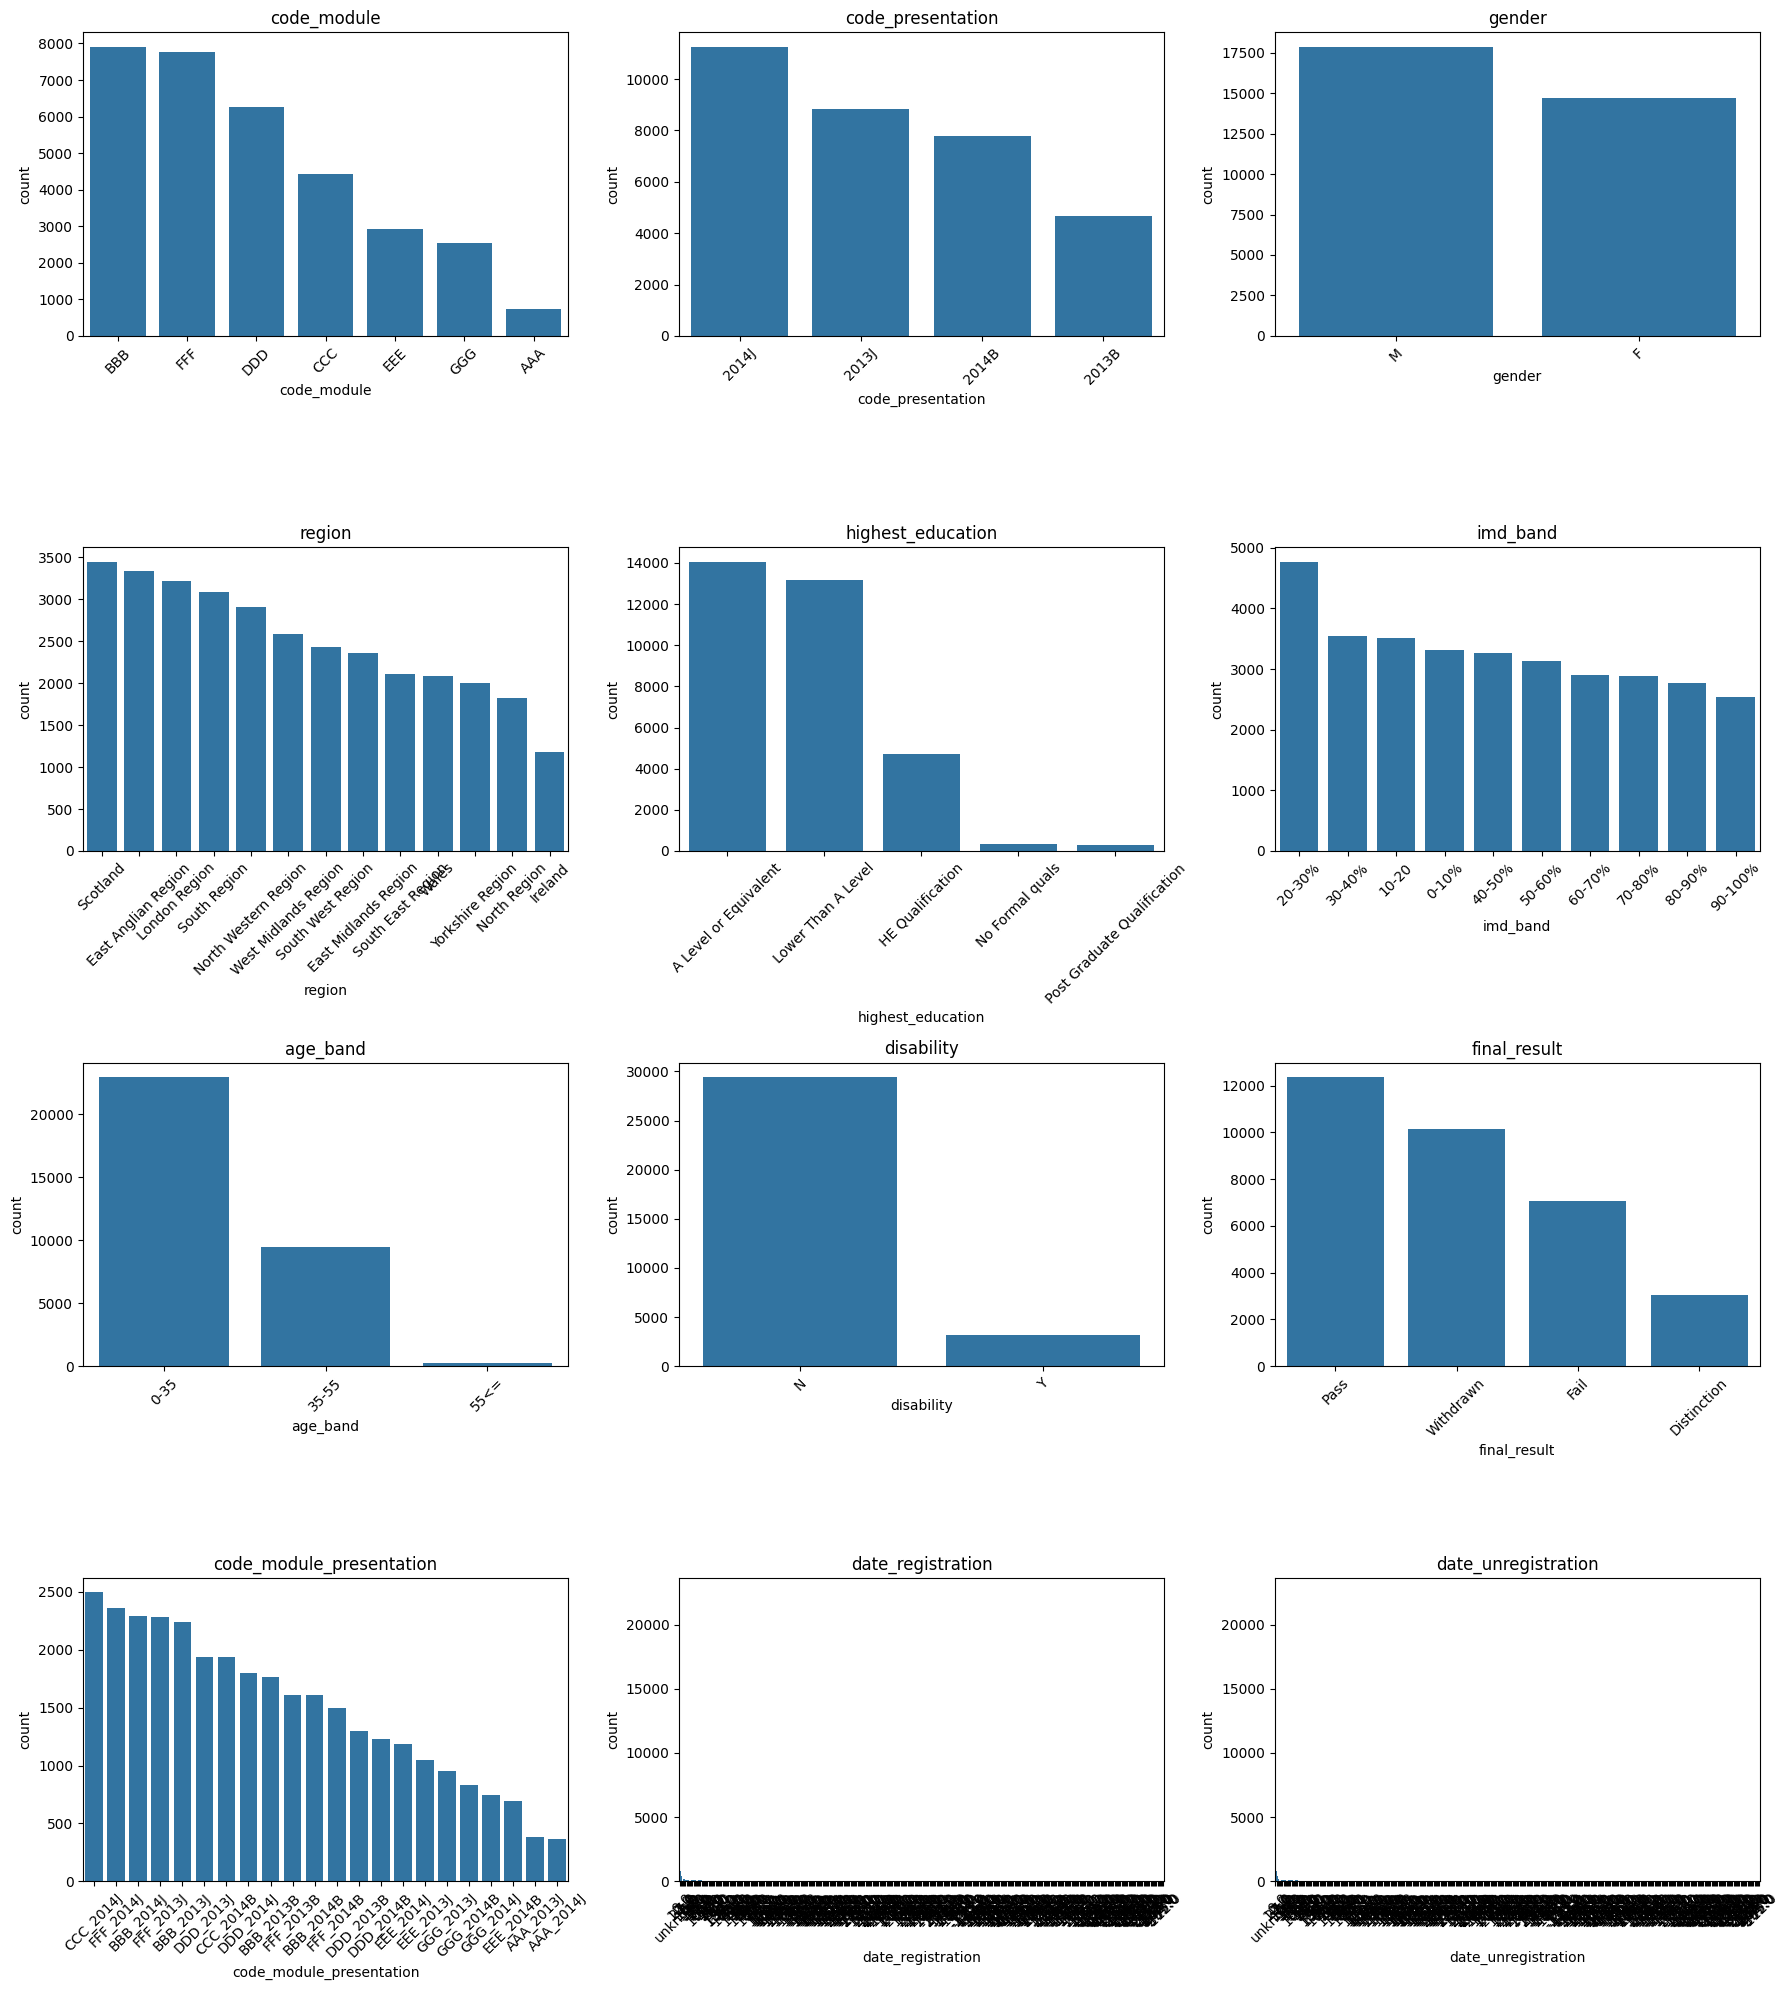

In [65]:
###countplot for all categorical columns
import math

n = len(categorical_cols)
cols = 3
rows = math.ceil(n / cols)

plt.figure(figsize=(18, rows * 5))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(rows, cols, i)
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.xticks(rotation=45)
    plt.title(col)

plt.tight_layout()
plt.show()

In [66]:
###univariate EDA for all numerical columns
numerical_cols = df.select_dtypes(include=['int64','float64']).columns

print(numerical_cols)

Index(['id_student', 'num_of_prev_attempts', 'studied_credits', 'dataplus',
       'forumng', 'glossary', 'homepage', 'oucollaborate', 'oucontent',
       'resource', 'subpage', 'url', 'module_presentation_length',
       'total_weight_submitted', 'cumulative_score', 'avg_days_late',
       'total_late_submissions', 'total_assignments_done', 'normalized_grade'],
      dtype='object')


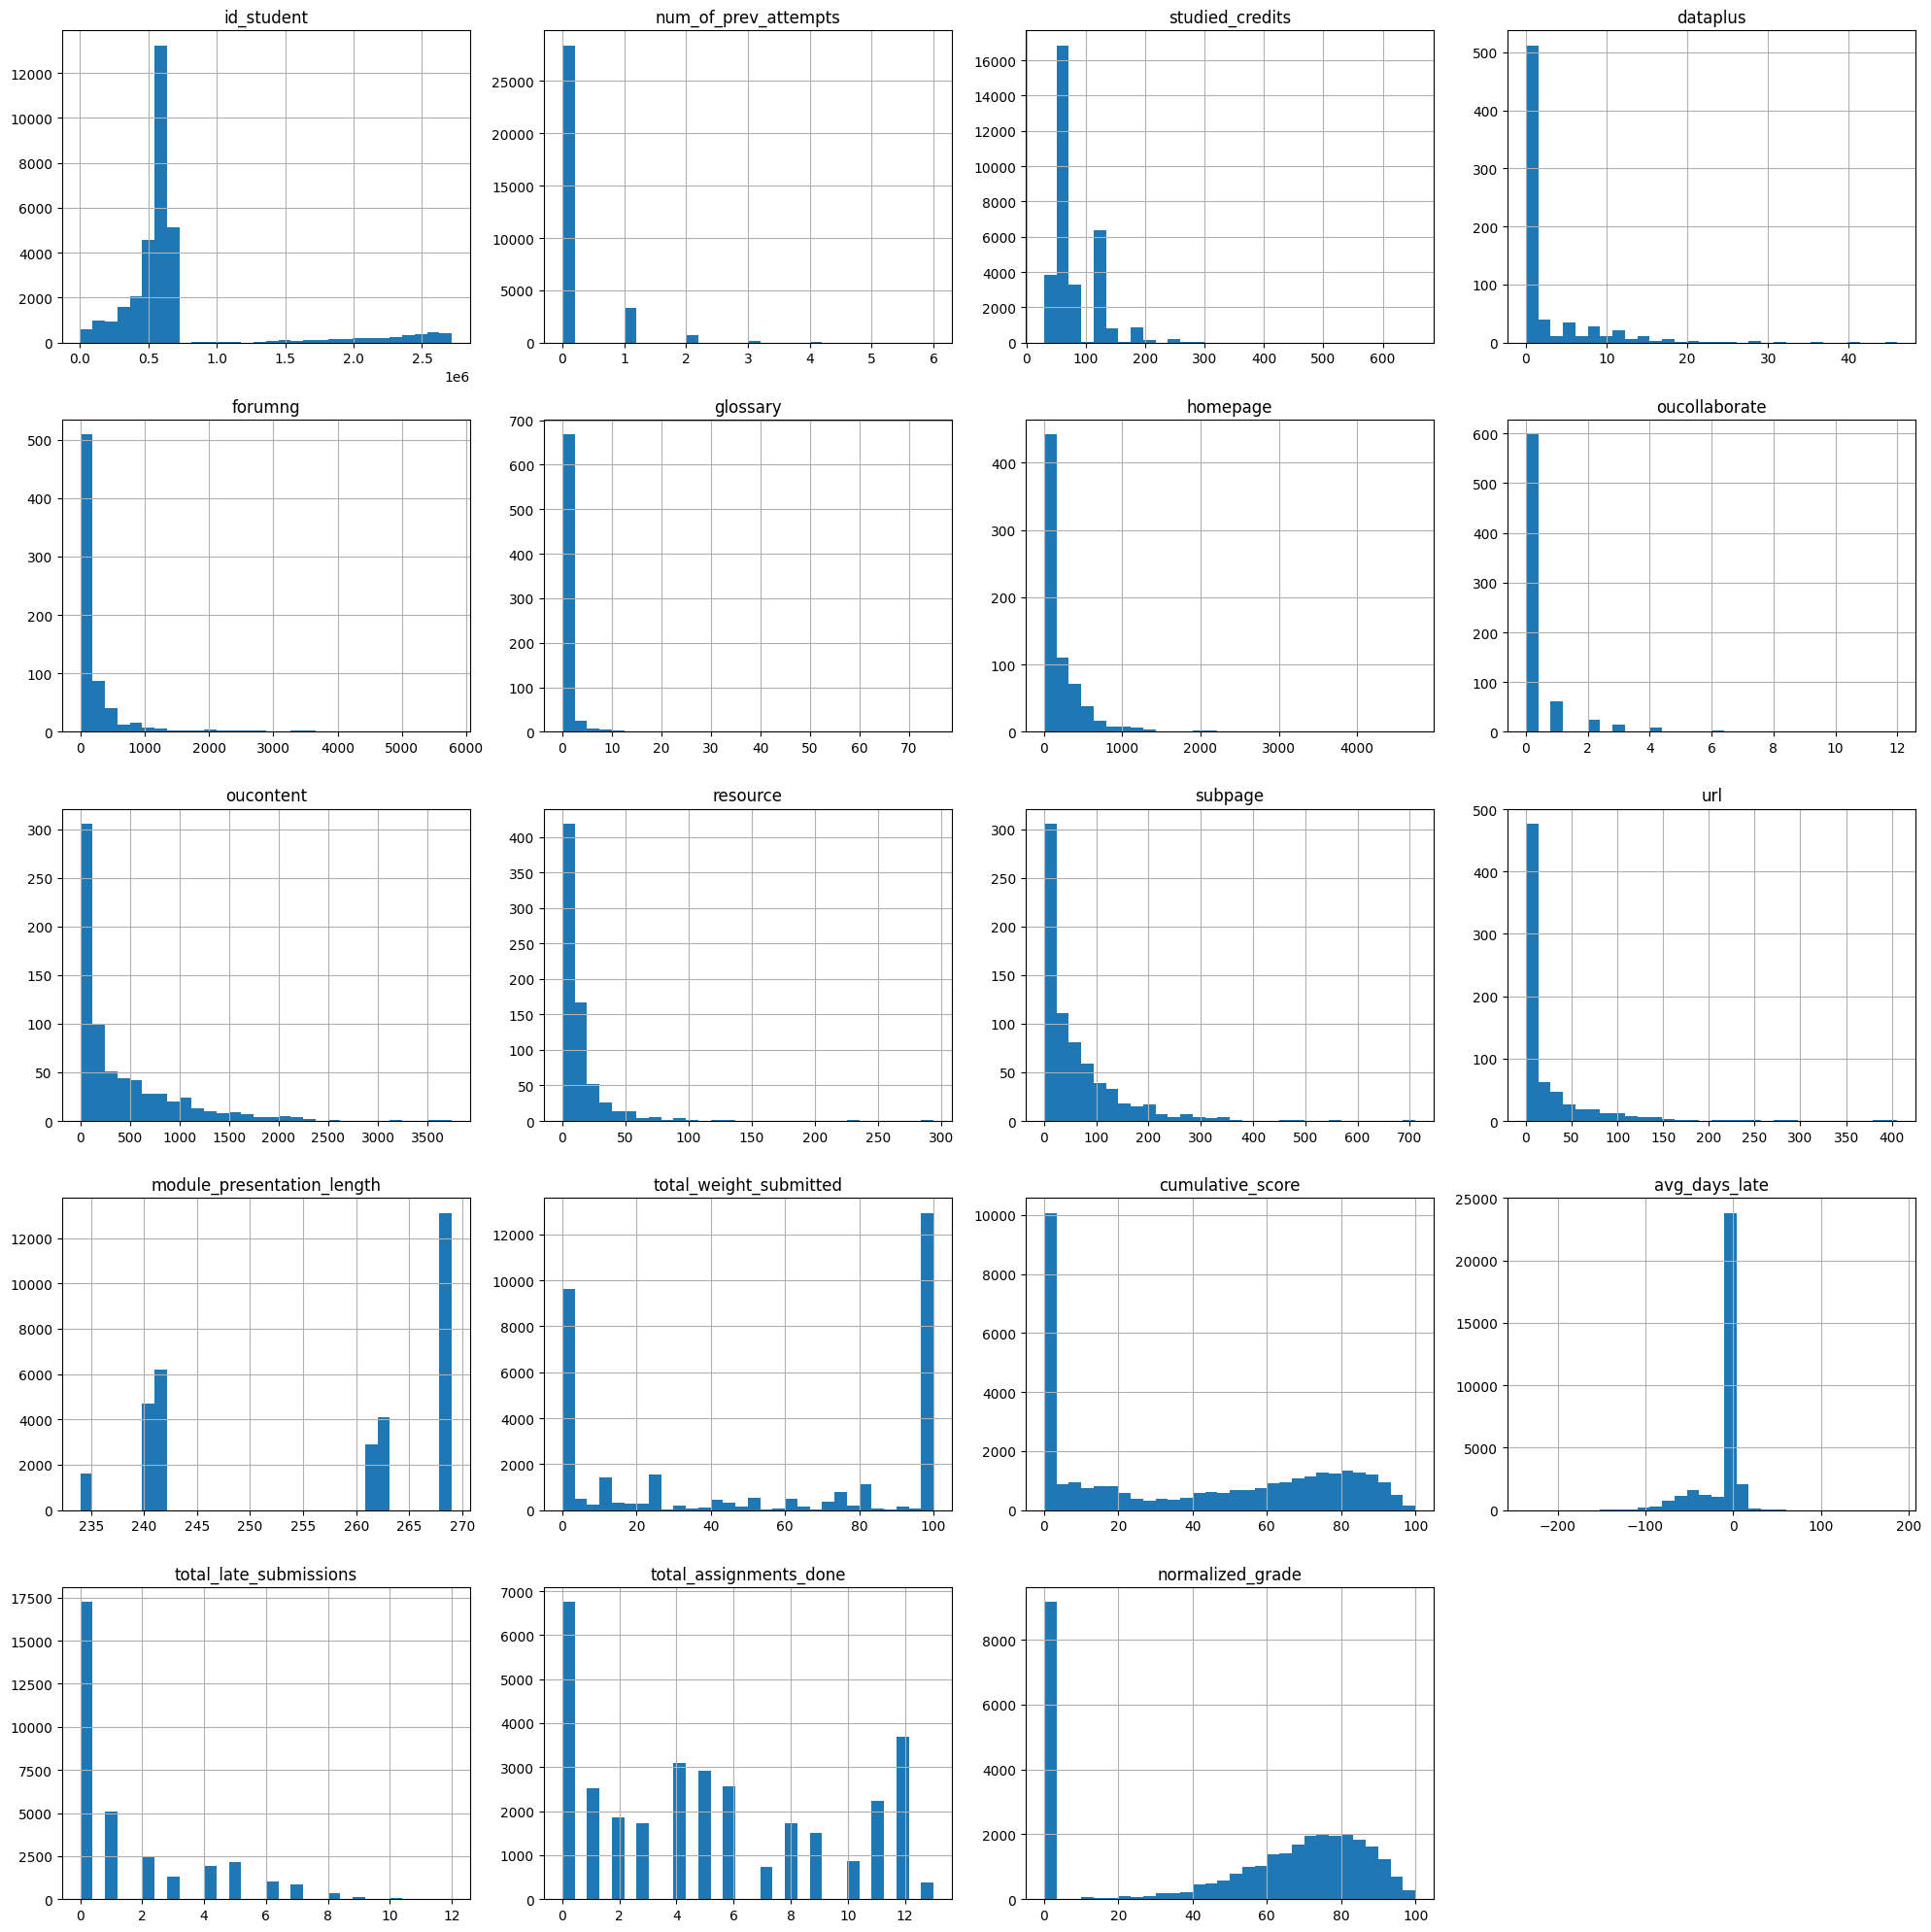

In [67]:
###Histograms
df[numerical_cols].hist(
    figsize=(20,20),
    bins=30
)

plt.tight_layout()
plt.show()

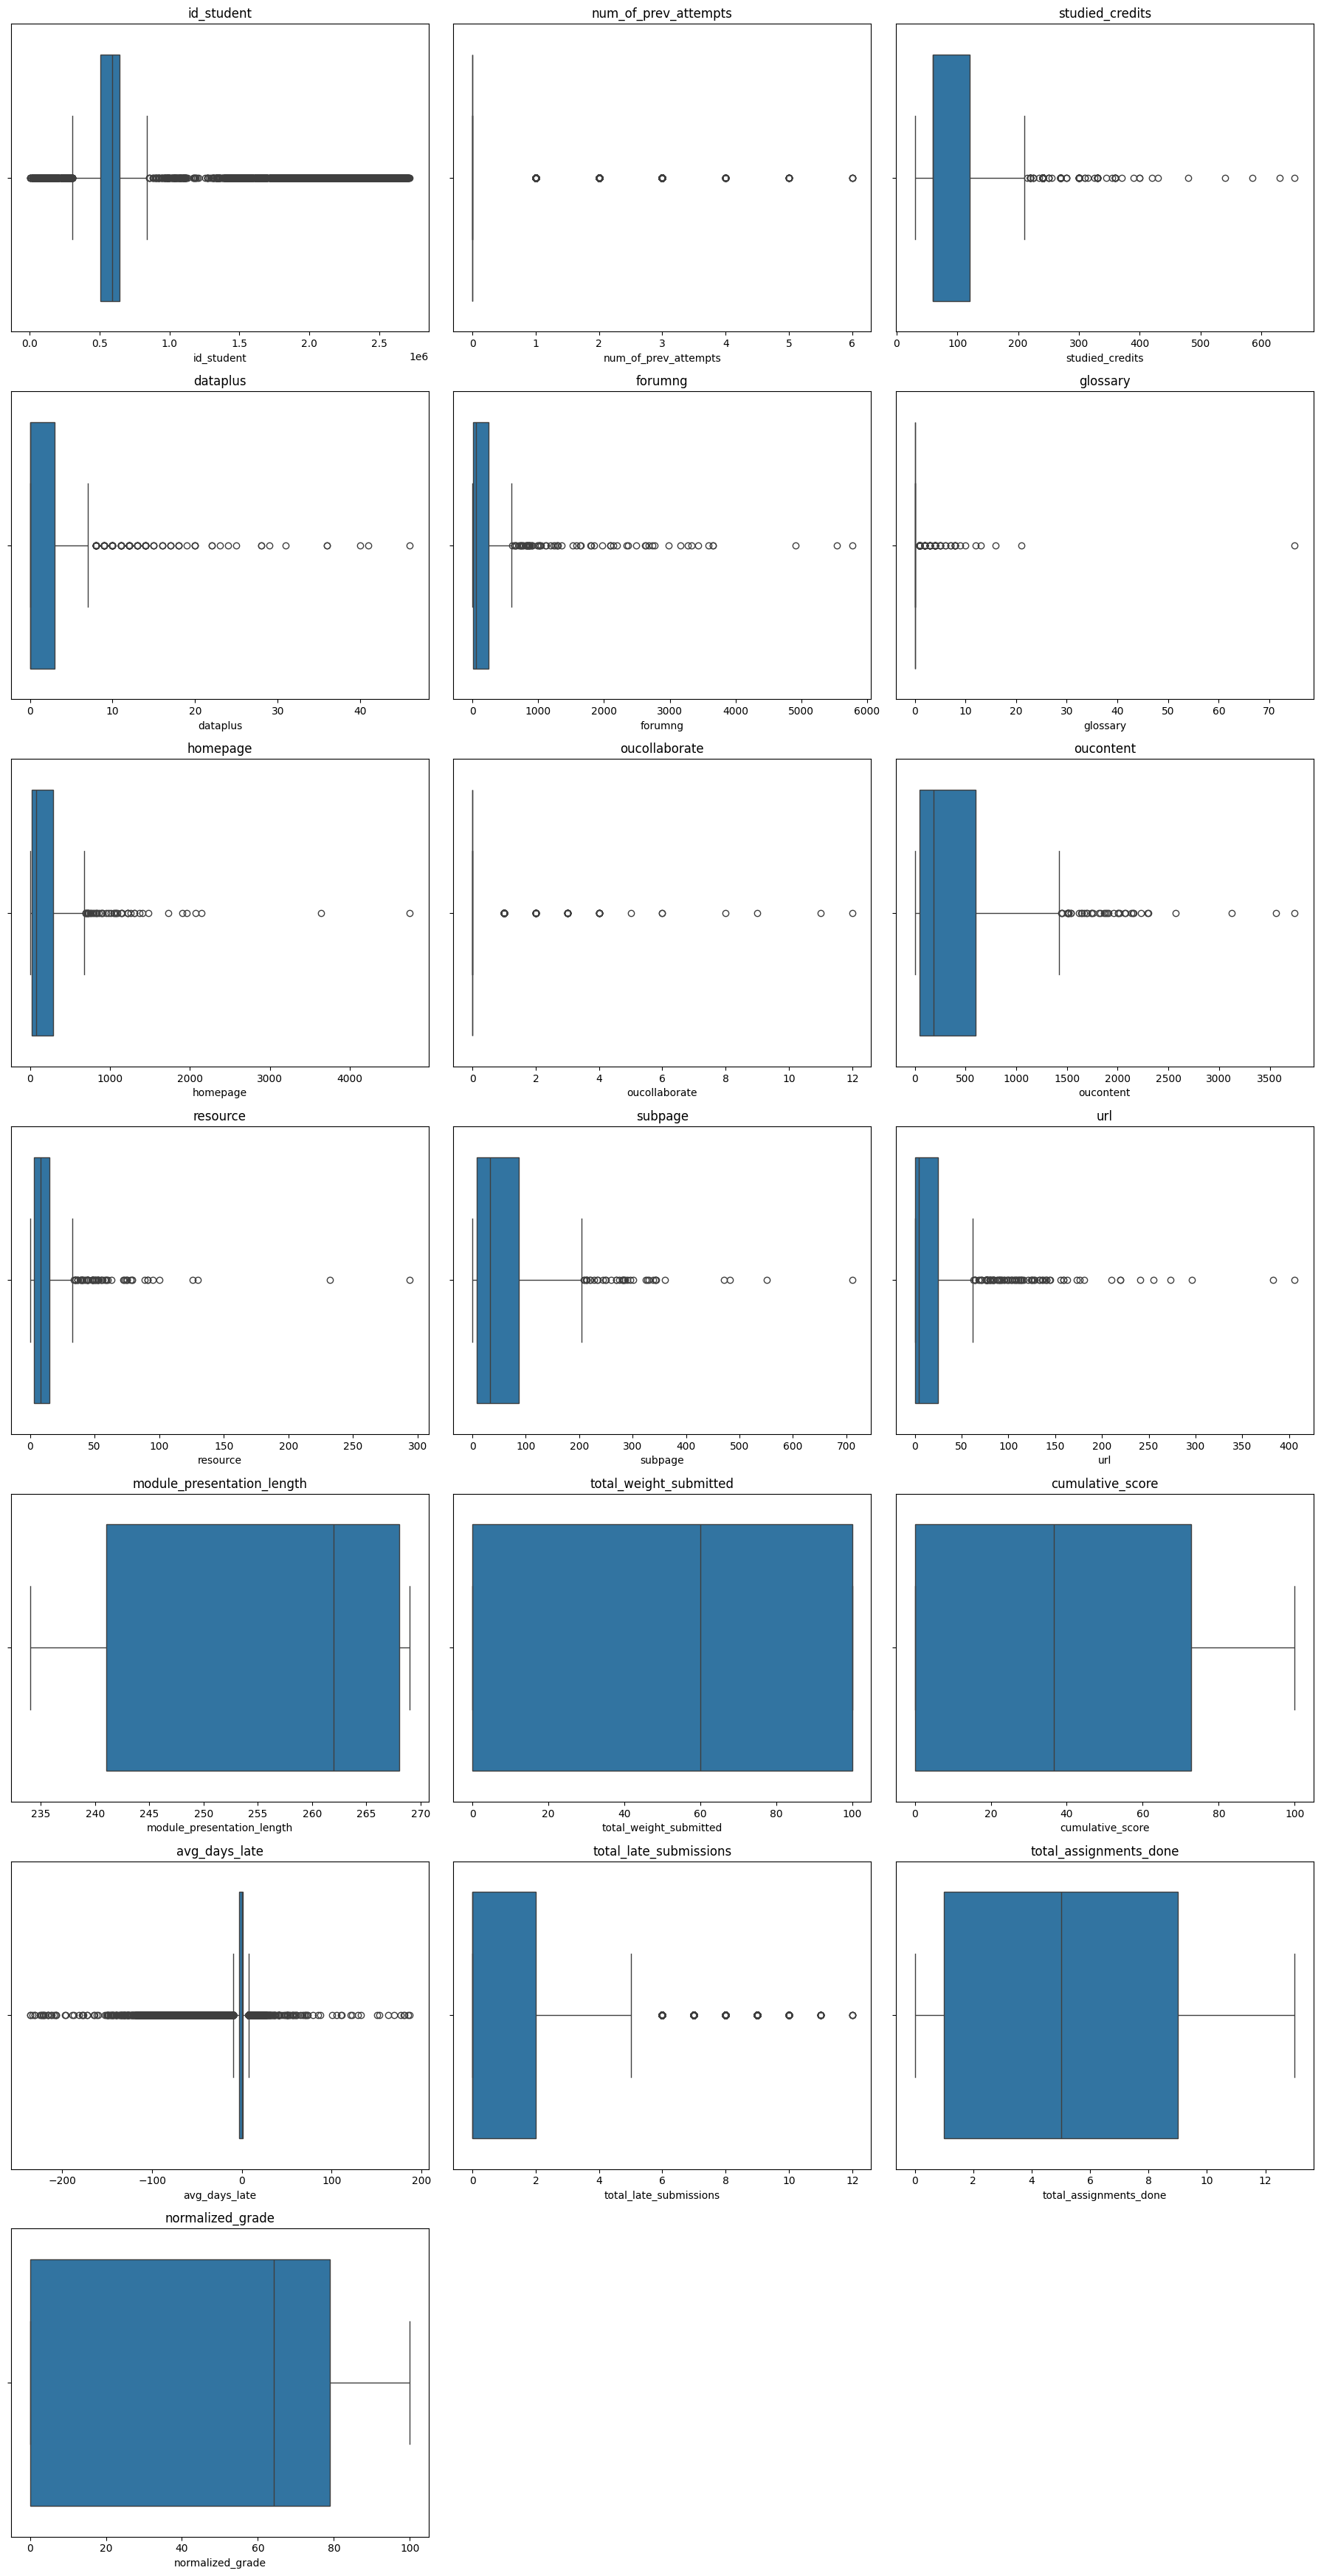

In [68]:
###Boxplots to detect outliers
import math

n = len(numerical_cols)
cols = 3
rows = math.ceil(n / cols)

plt.figure(figsize=(18, rows * 5))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(rows, cols, i)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [ ]:
###descriptive statistics
df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
id_student,32593.0,706687.669131,549167.313855,3733.0,508573.00,590310.000000,644453.000,2716795.0
num_of_prev_attempts,32593.0,0.163225,0.479758,0.0,0.00,0.000000,0.000,6.0
studied_credits,32593.0,79.758691,41.071900,30.0,60.00,60.000000,120.000,655.0
dataplus,713.0,2.733520,5.831839,0.0,0.00,0.000000,3.000,46.0
forumng,713.0,270.577840,632.149108,0.0,9.00,53.000000,247.000,5774.0
glossary,713.0,0.617111,3.269812,0.0,0.00,0.000000,0.000,75.0
homepage,713.0,215.269285,362.647975,0.0,22.00,80.000000,286.000,4747.0
oucollaborate,713.0,0.338008,1.084583,0.0,0.00,0.000000,0.000,12.0
oucontent,713.0,411.920056,531.046738,0.0,46.00,185.000000,597.000,3745.0
resource,713.0,13.190743,21.166676,0.0,3.00,8.000000,15.000,294.0


In [70]:
###categorical variables with final results
categorical_cols = df.select_dtypes(include="object").columns.tolist()

# Remove target variable from predictor list
categorical_cols.remove("final_result")

print(categorical_cols)

['code_module', 'code_presentation', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'disability', 'code_module_presentation', 'date_registration', 'date_unregistration']


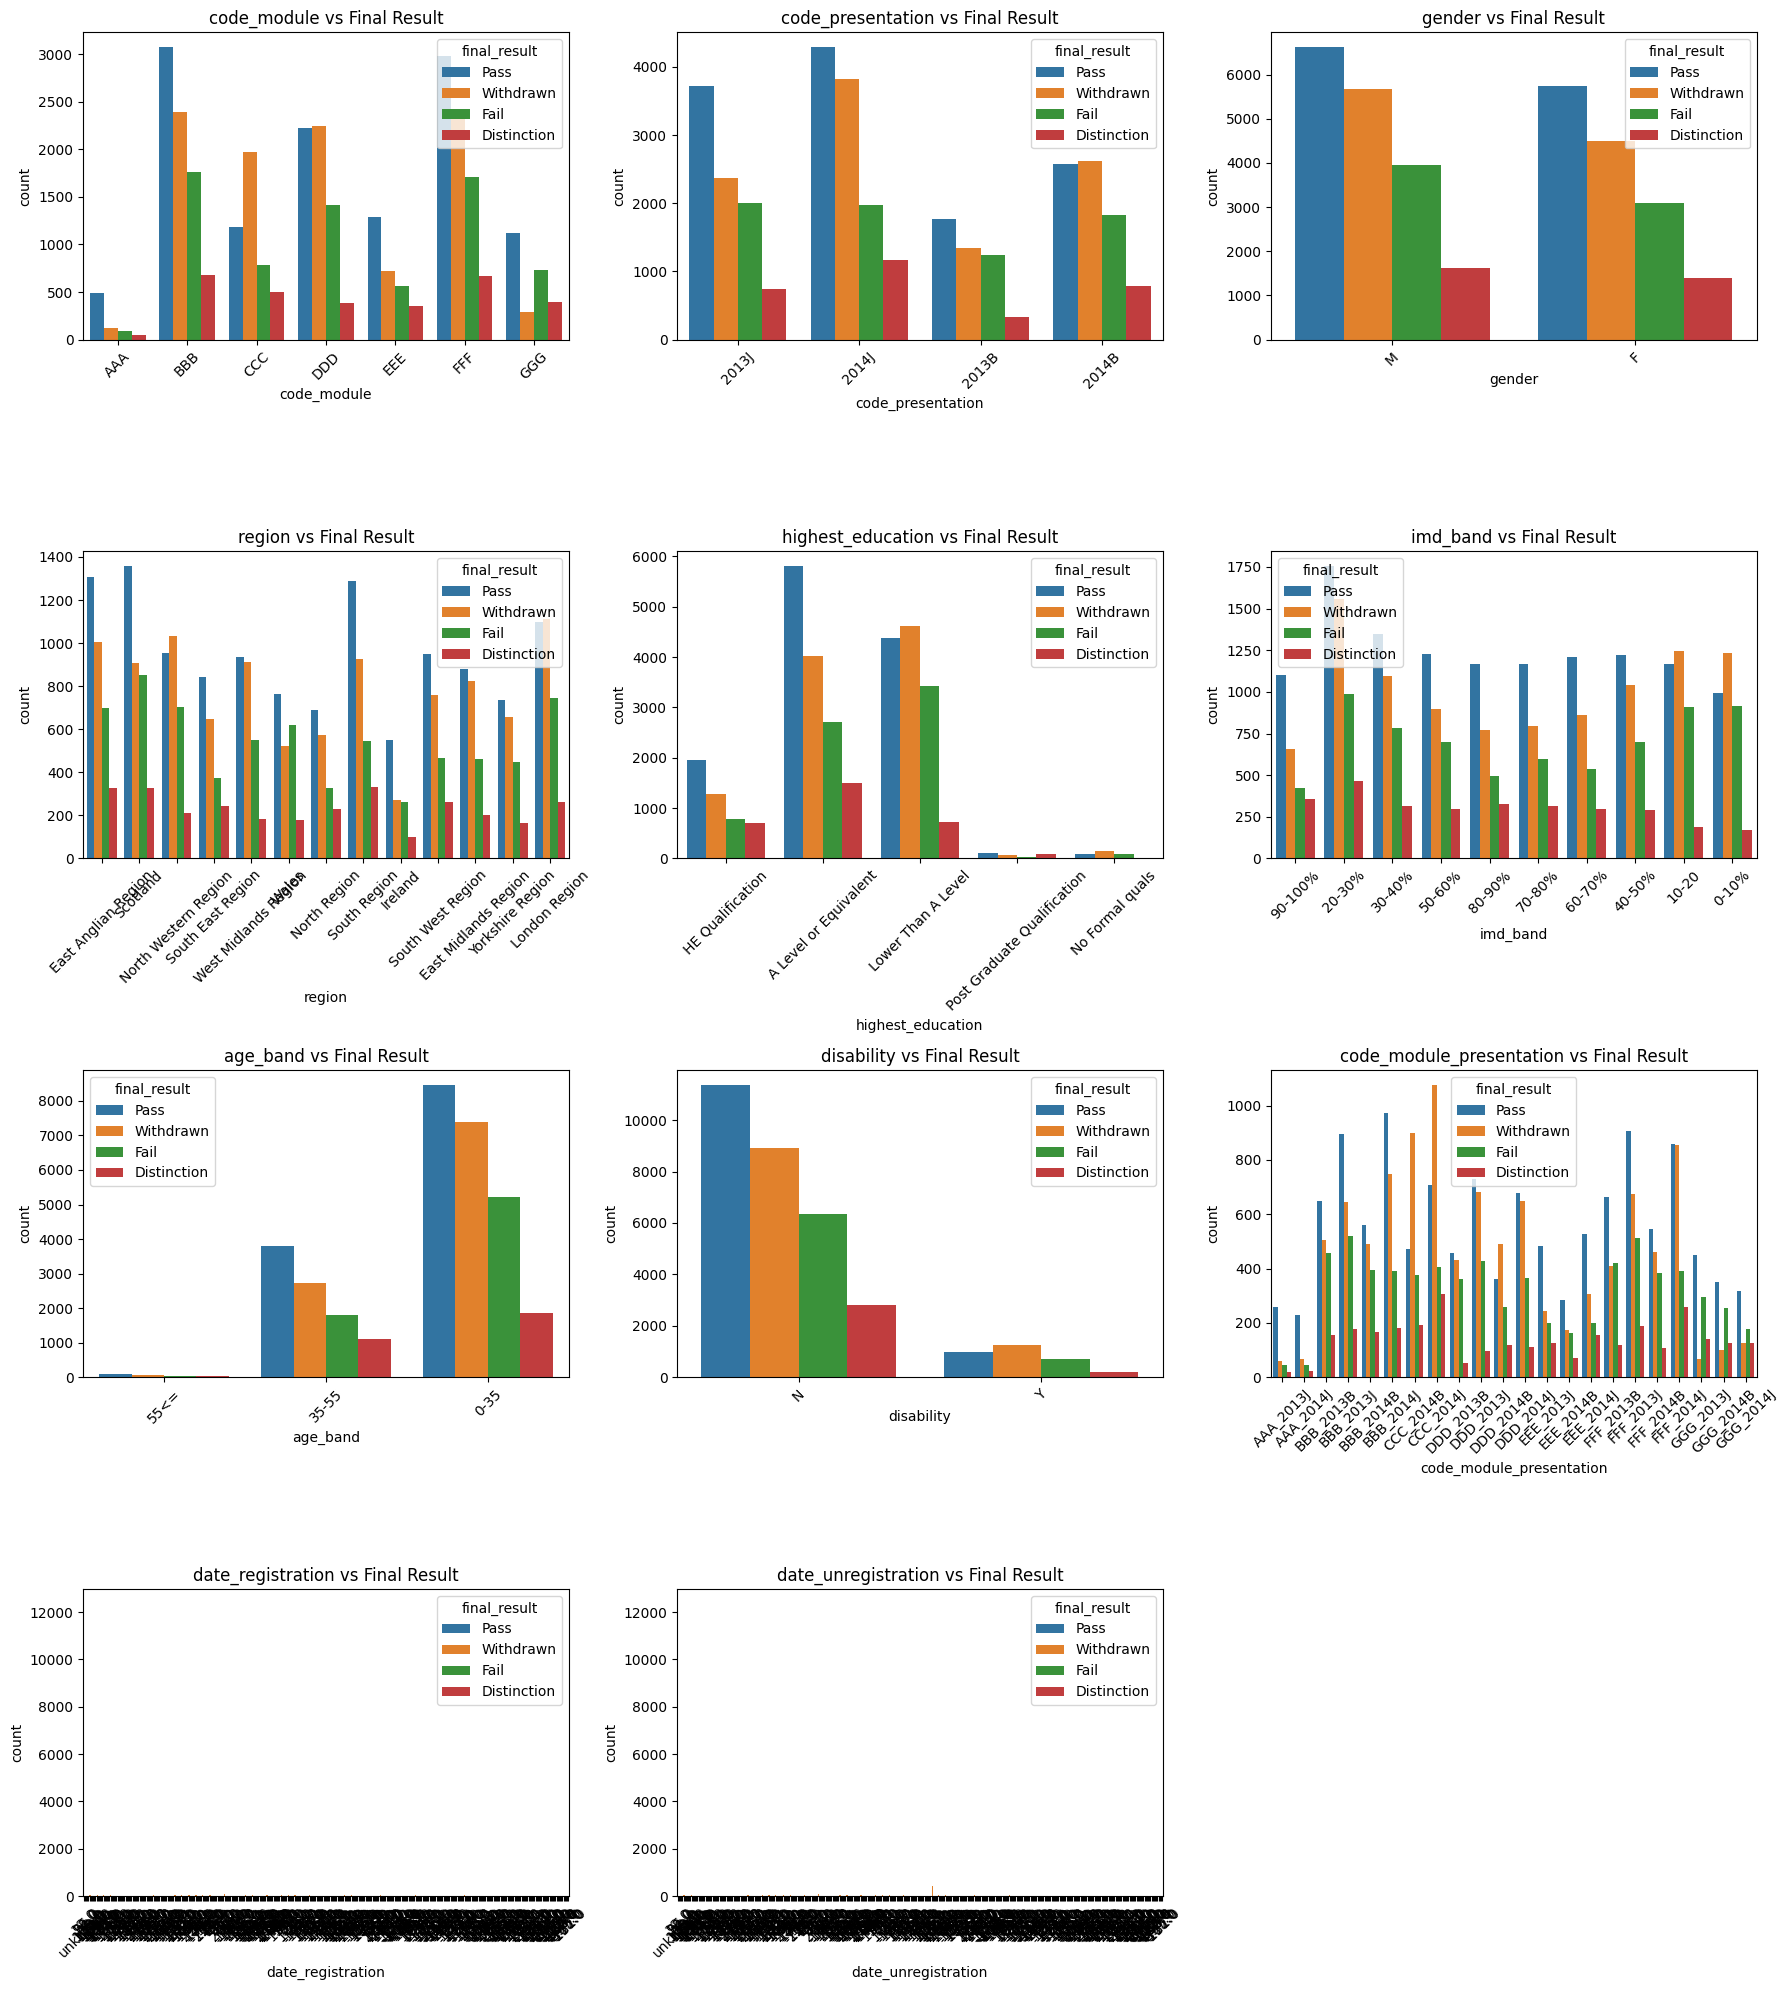

In [71]:
###count plots
import math

n = len(categorical_cols)
cols = 3
rows = math.ceil(n / cols)

plt.figure(figsize=(18, rows * 5))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(rows, cols, i)
    sns.countplot(data=df, x=col, hue="final_result")
    plt.xticks(rotation=45)
    plt.title(f"{col} vs Final Result")

plt.tight_layout()
plt.show()

In [72]:
###Numerical values with final results

numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns

print(numerical_cols)

Index(['id_student', 'num_of_prev_attempts', 'studied_credits', 'dataplus',
       'forumng', 'glossary', 'homepage', 'oucollaborate', 'oucontent',
       'resource', 'subpage', 'url', 'module_presentation_length',
       'total_weight_submitted', 'cumulative_score', 'avg_days_late',
       'total_late_submissions', 'total_assignments_done', 'normalized_grade'],
      dtype='object')


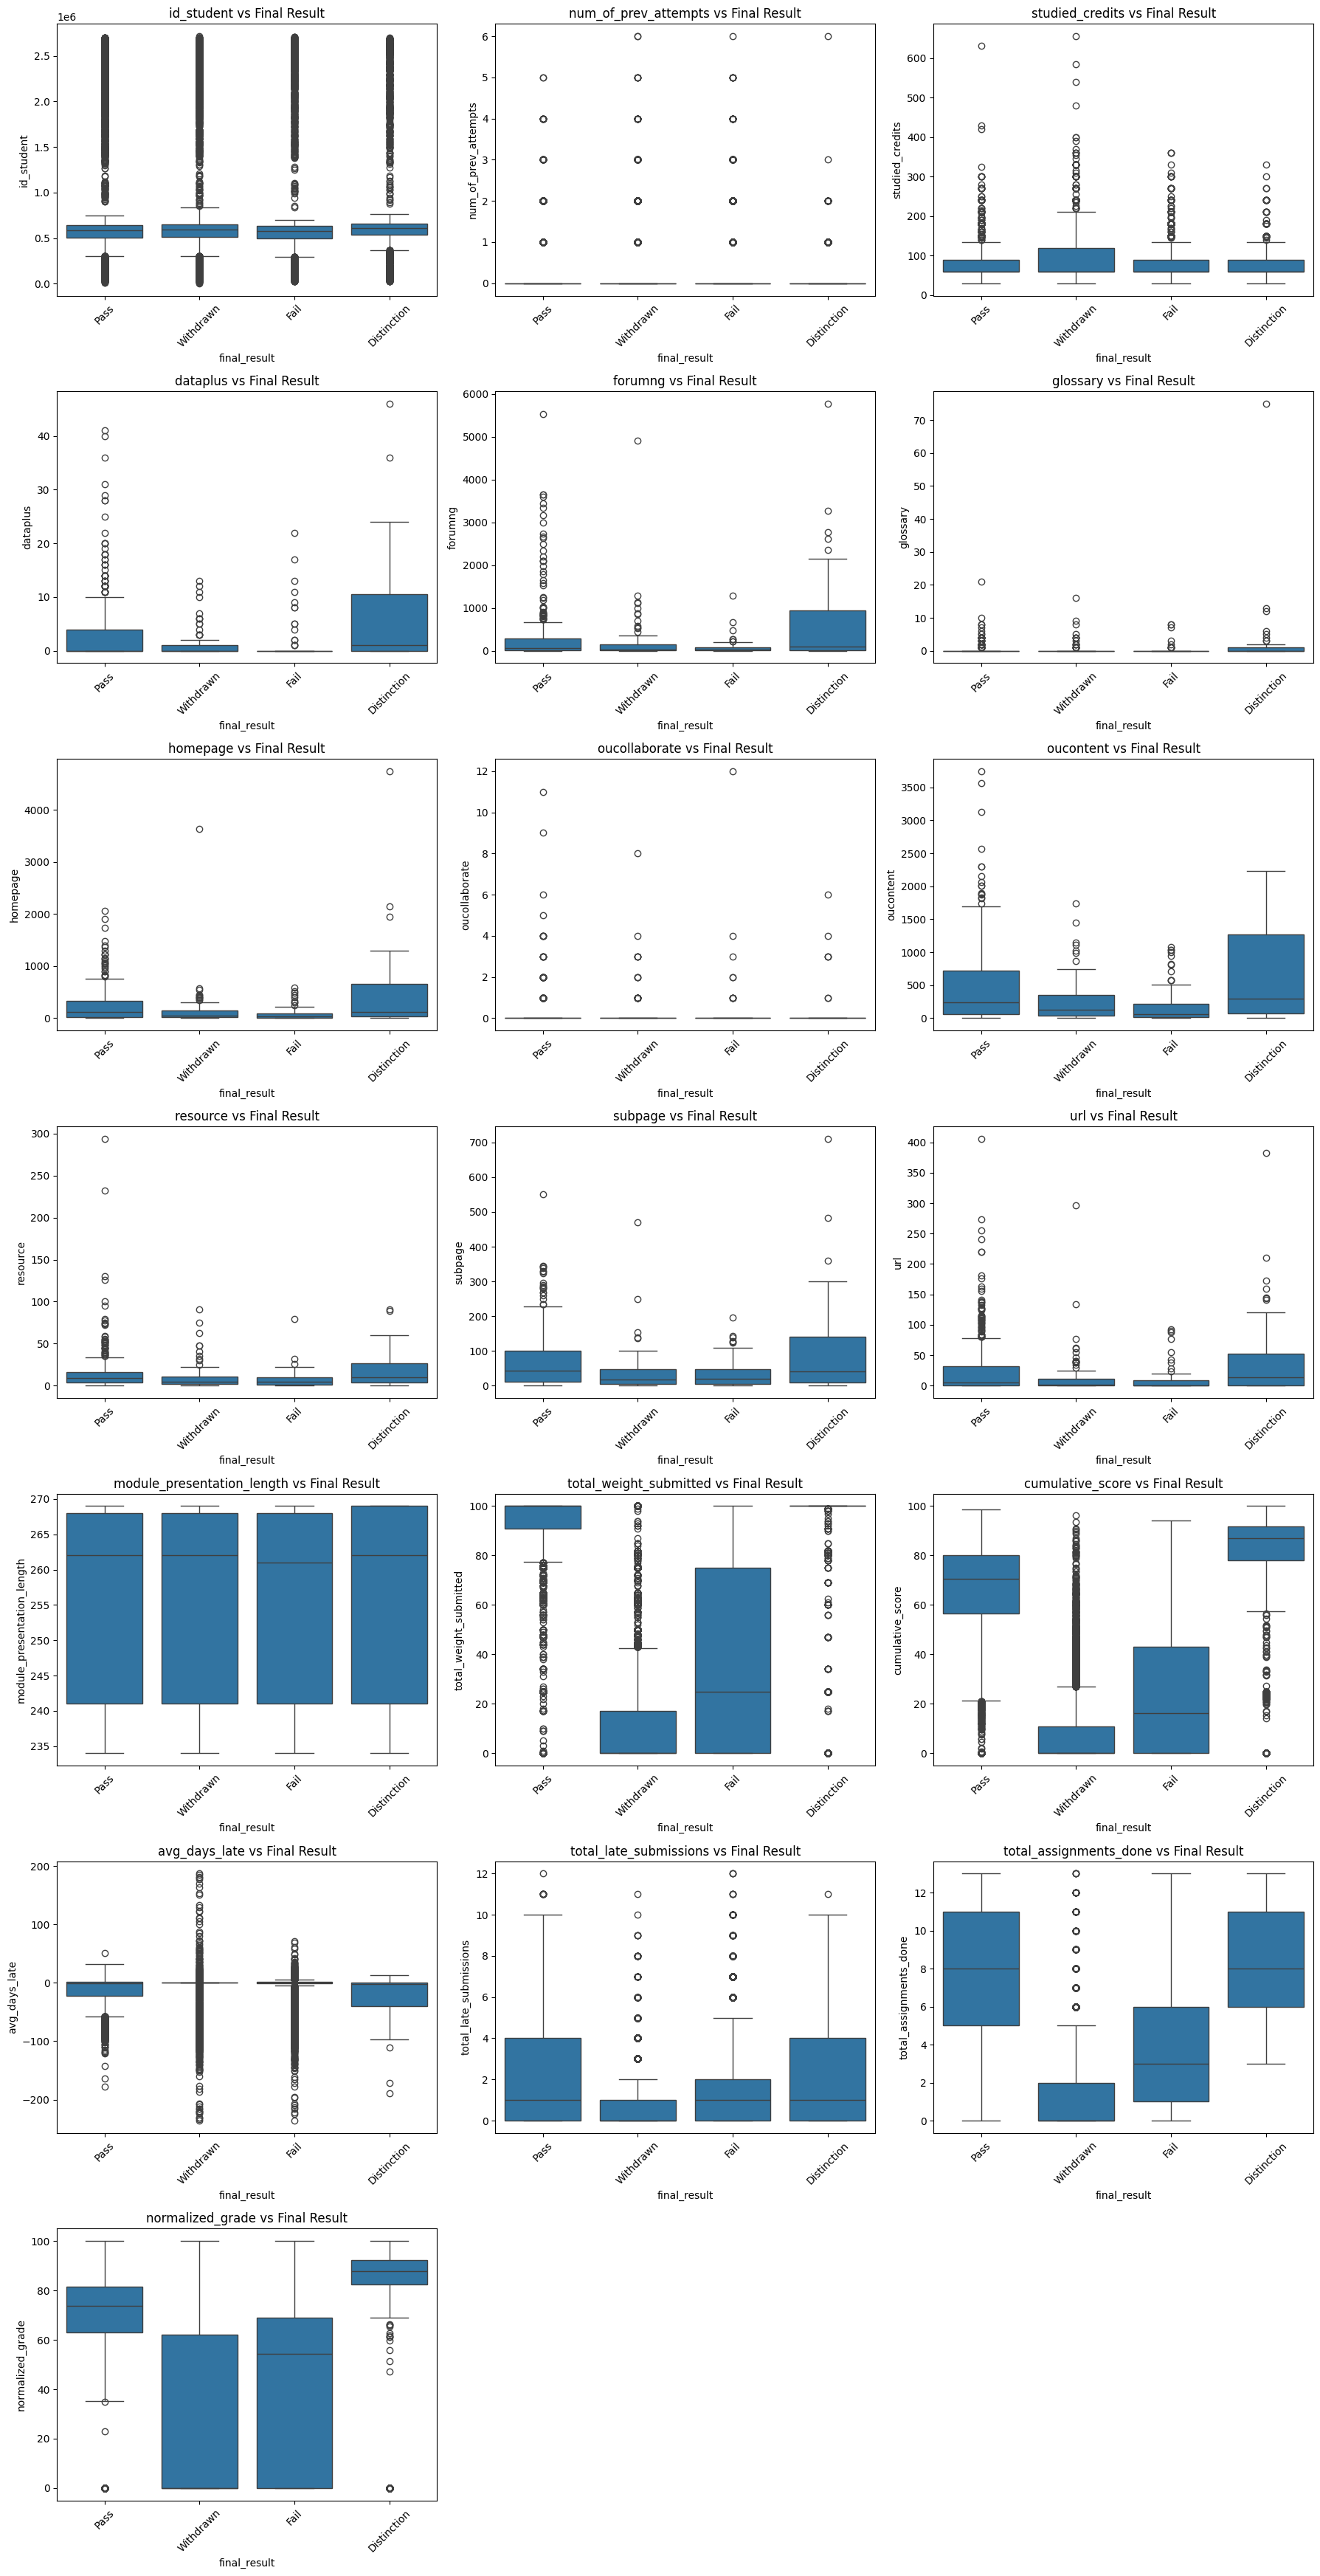

In [73]:
###Boxplots
import math

n = len(numerical_cols)
cols = 3
rows = math.ceil(n / cols)

plt.figure(figsize=(18, rows * 5))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(rows, cols, i)
    sns.boxplot(data=df, x="final_result", y=col)
    plt.xticks(rotation=45)
    plt.title(f"{col} vs Final Result")

plt.tight_layout()
plt.show()

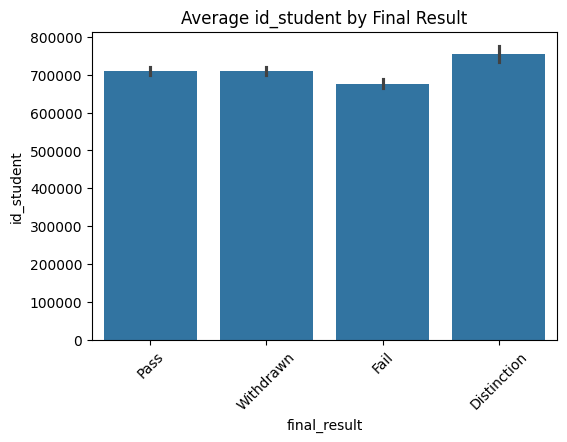

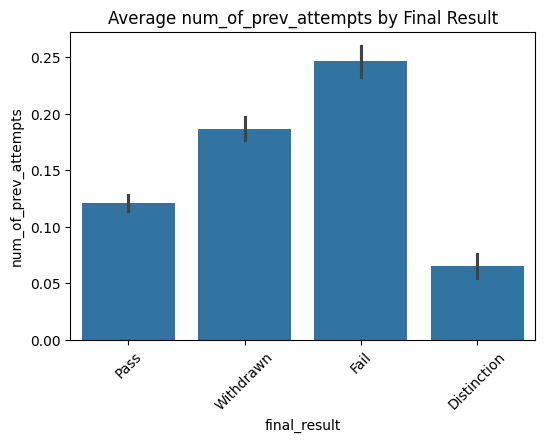

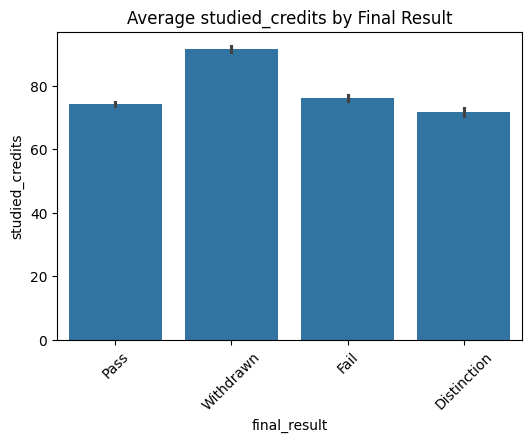

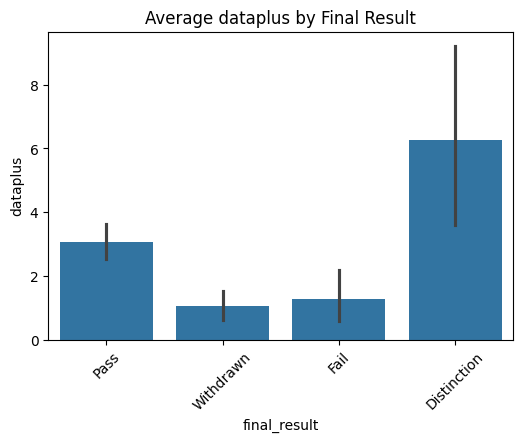

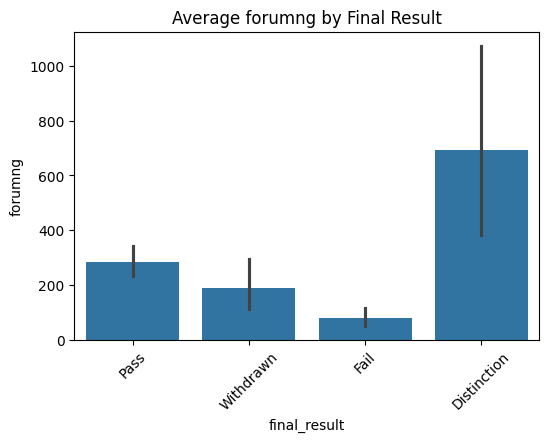

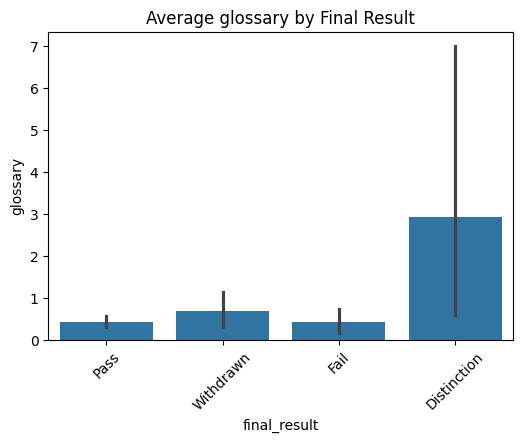

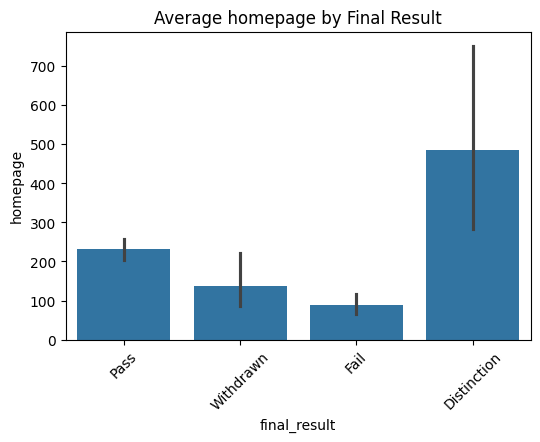

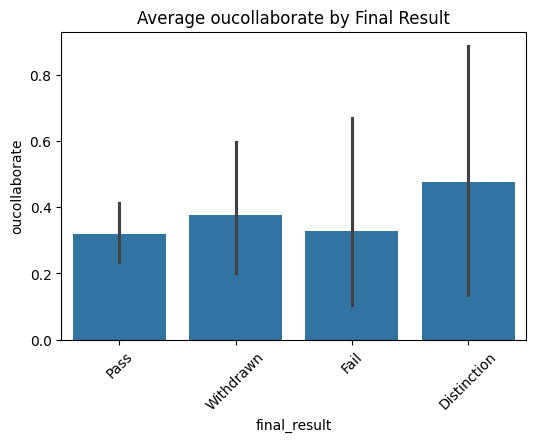

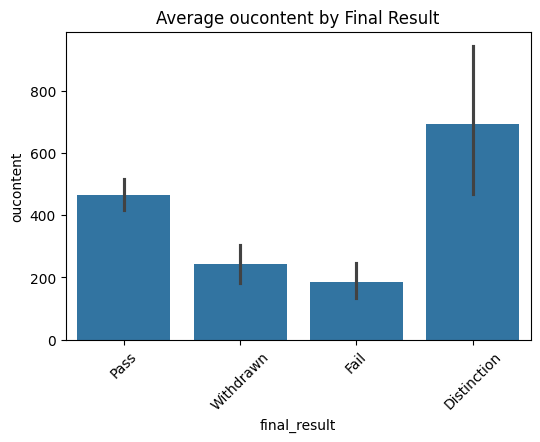

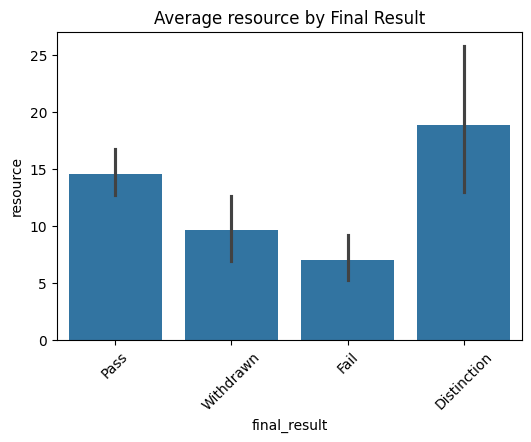

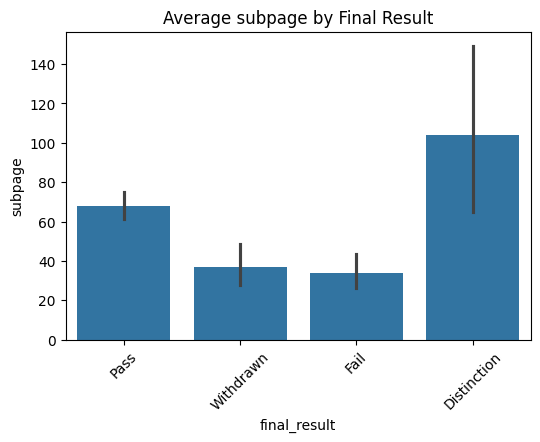

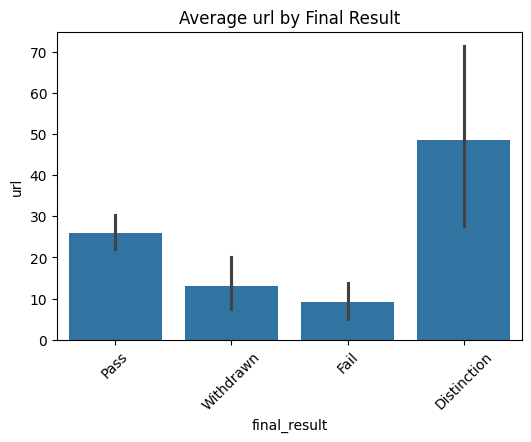

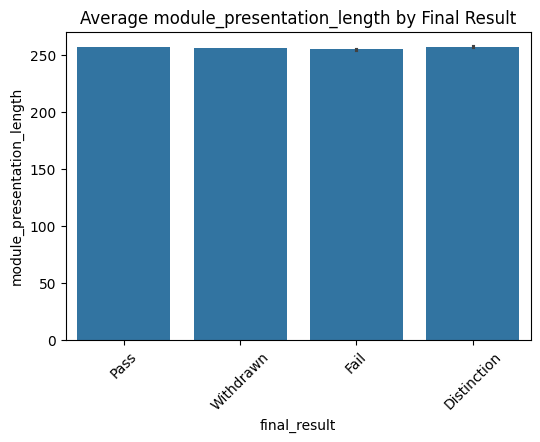

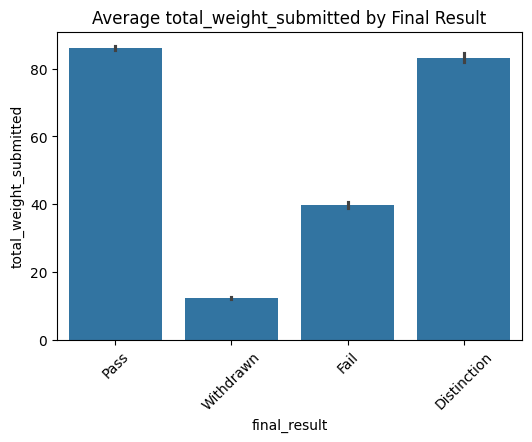

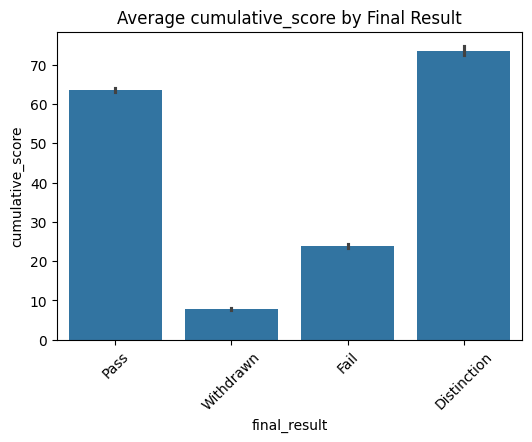

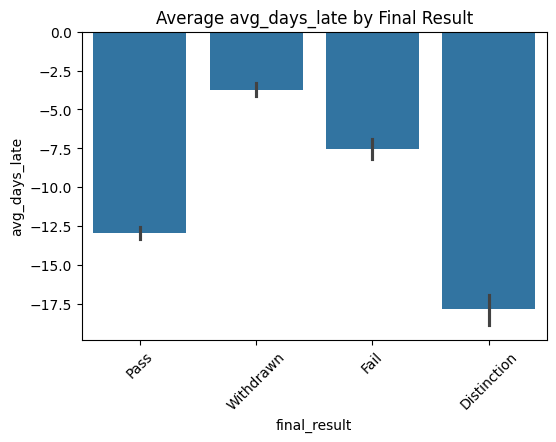

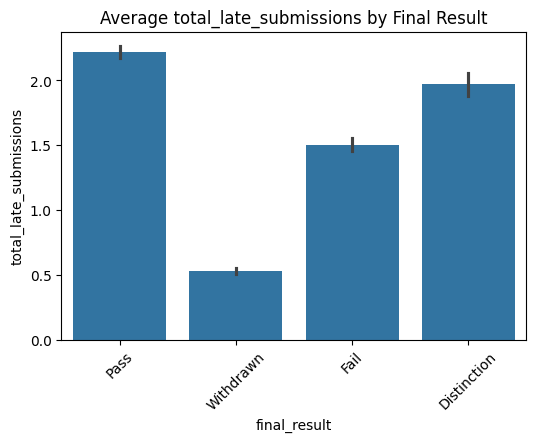

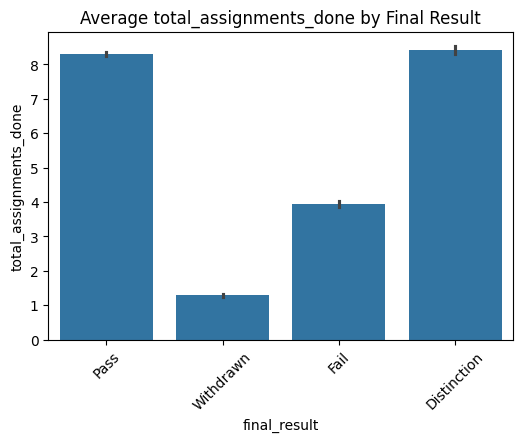

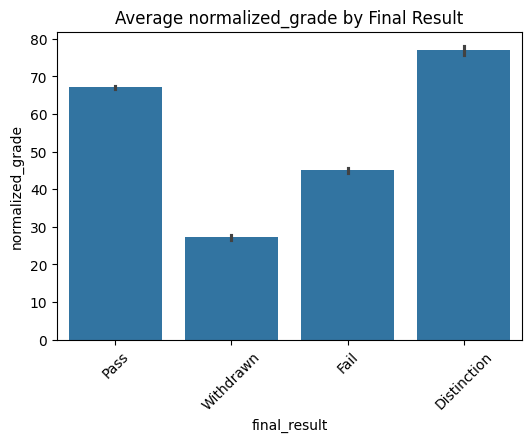

In [74]:
###Numerical values with final results mean value
for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.barplot(data=df, x="final_result", y=col)
    plt.title(f"Average {col} by Final Result")
    plt.xticks(rotation=45)
    plt.show()

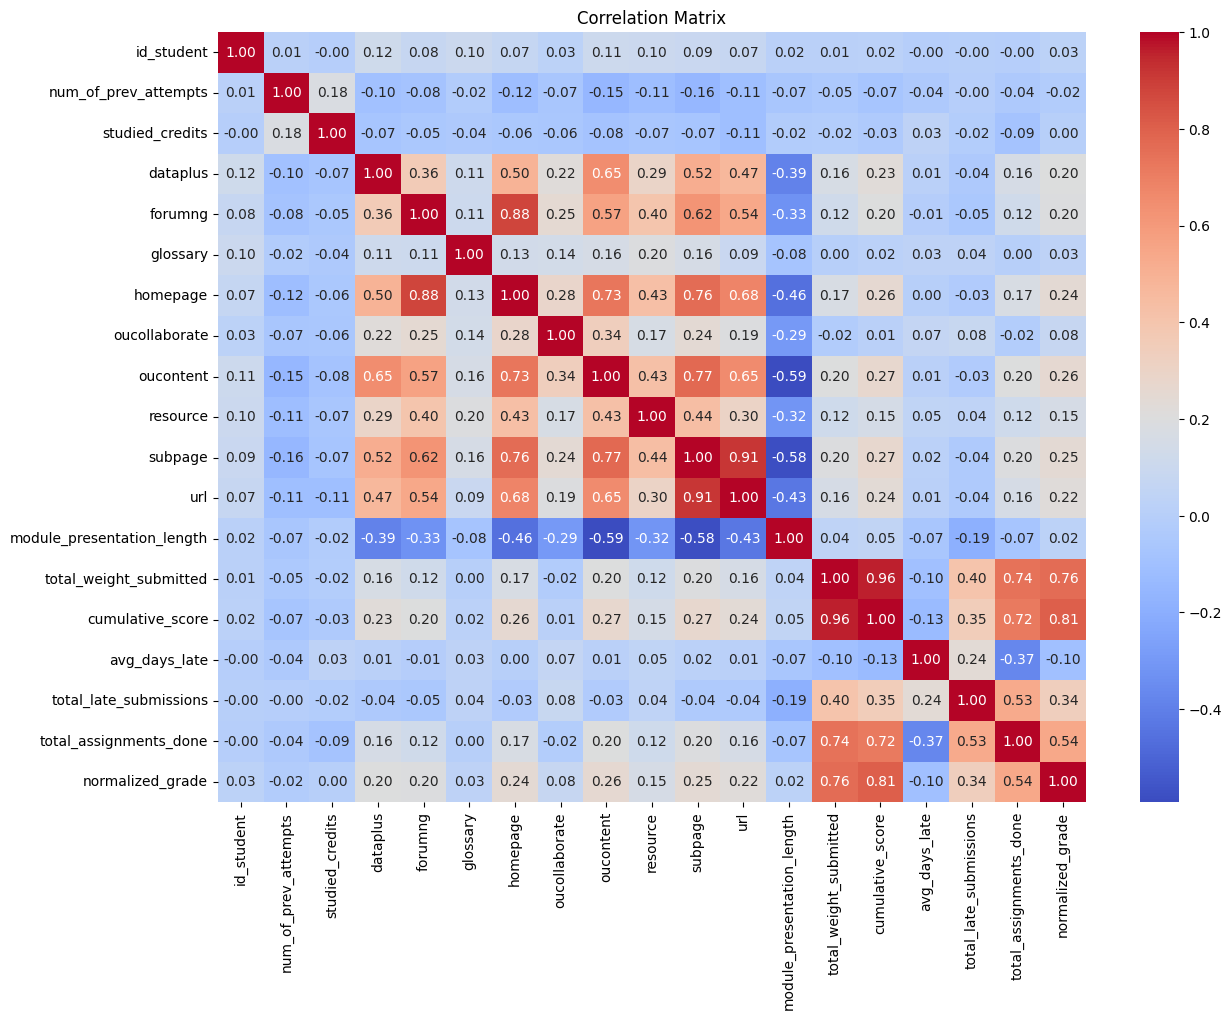

In [75]:
### corelation with numeric features
plt.figure(figsize=(14,10))

corr = df[numerical_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [76]:
###crosstab
###Percentages for every categorical variable against final_result
for col in categorical_cols:
    print(f"\n{'='*60}")
    print(f"{col} vs final_result")
    print(pd.crosstab(df[col], df["final_result"], normalize="index") * 100)


code_module vs final_result
final_result  Distinction       Fail       Pass  Withdrawn
code_module                                               
AAA              5.882353  12.165775  65.106952  16.844920
BBB              8.559869  22.341636  38.905045  30.193450
CCC             11.231394  17.613893  26.612539  44.542174
DDD              6.106505  22.512755  35.507015  35.873724
EEE             12.133606  19.154738  44.103613  24.608044
FFF              8.631796  22.043288  38.366400  30.958516
GGG             15.627466  28.729282  44.119968  11.523283

code_presentation vs final_result
final_result       Distinction       Fail       Pass  Withdrawn
code_presentation                                              
2013B                 6.981213  26.494449  37.745517  28.778822
2013J                 8.468061  22.622951  42.125495  26.783493
2014B                10.046130  23.487955  32.983086  33.482829
2014J                10.337478  17.557726  38.126110  33.978686

gender vs final_resu

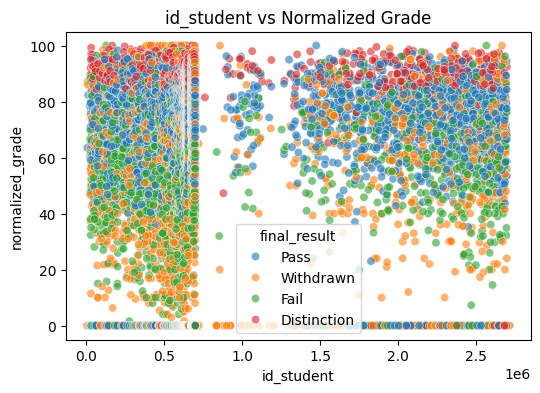

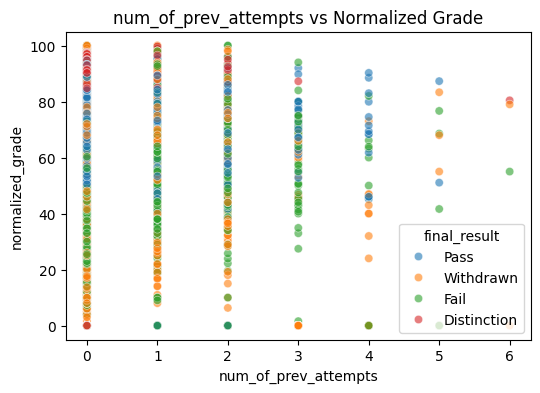

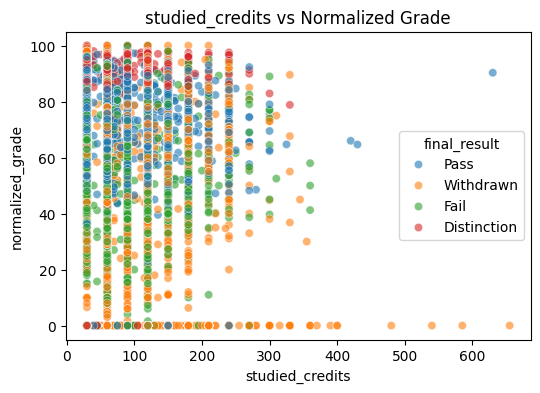

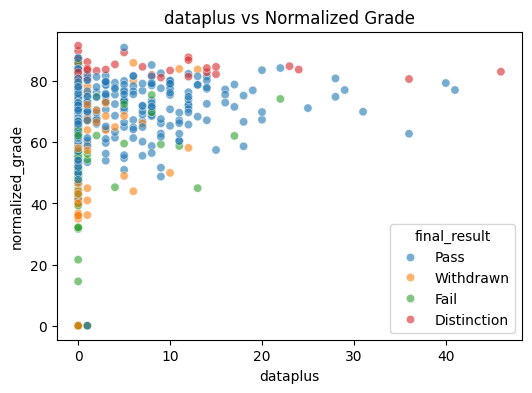

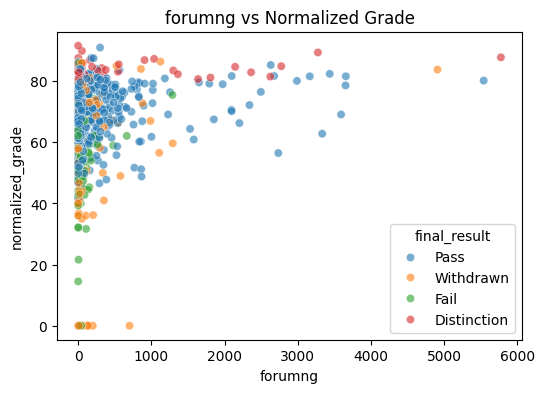

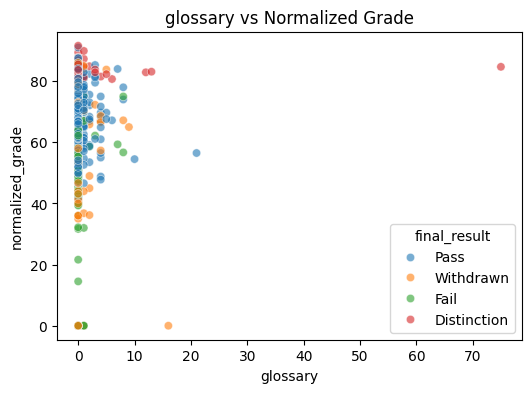

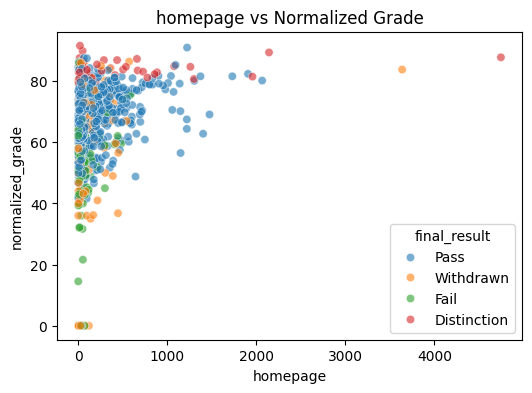

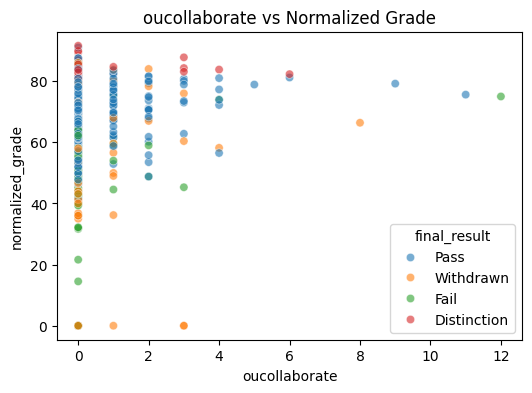

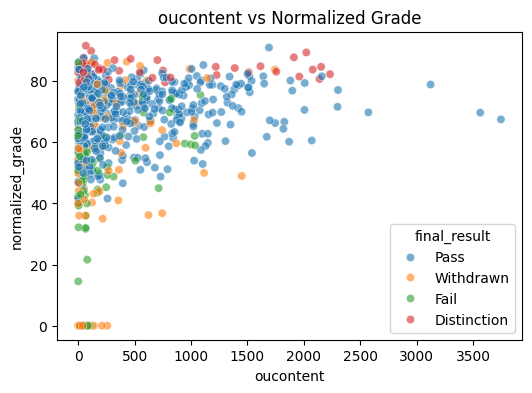

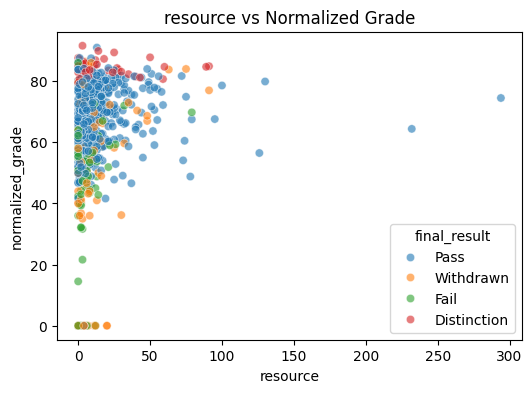

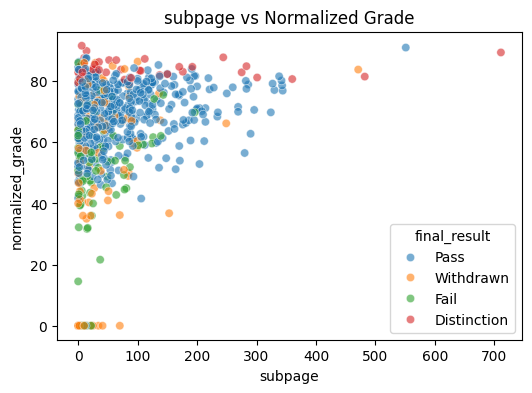

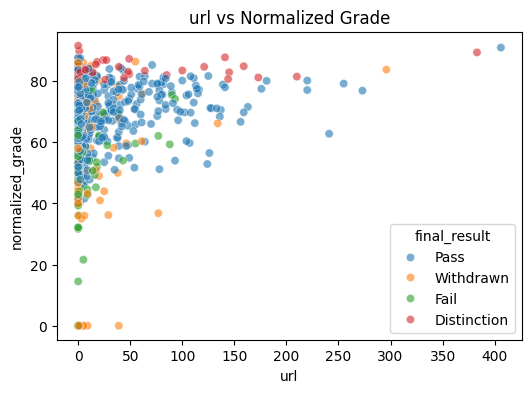

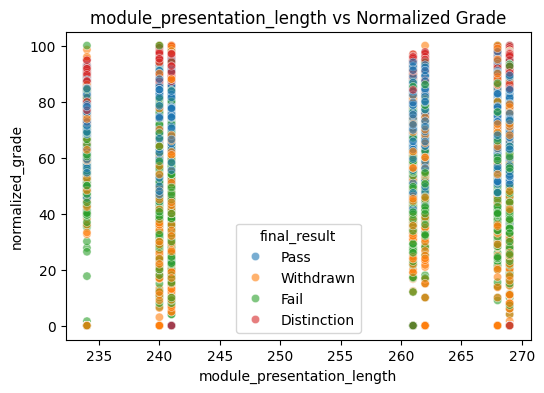

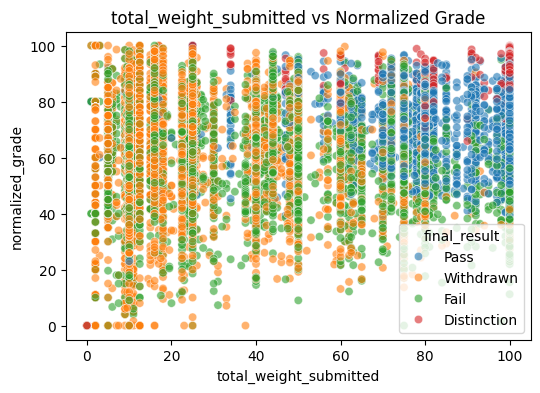

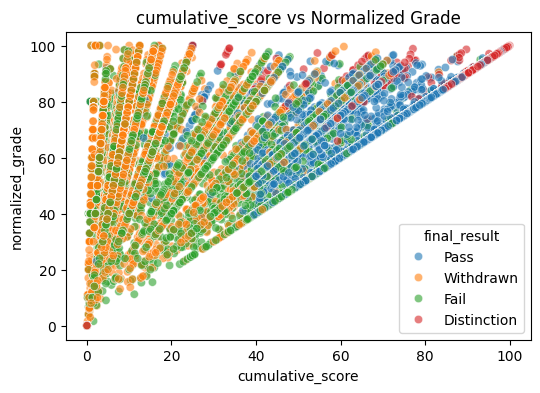

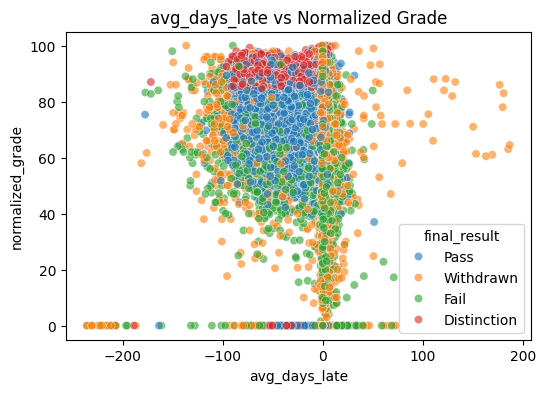

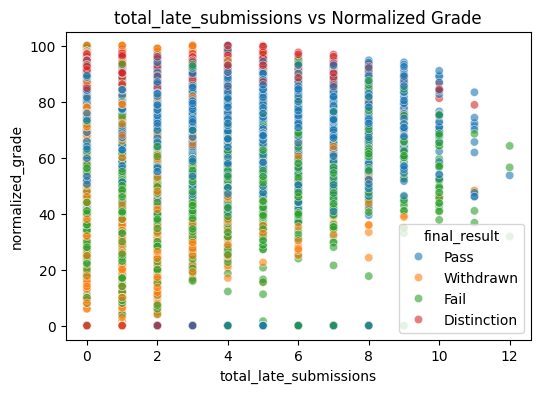

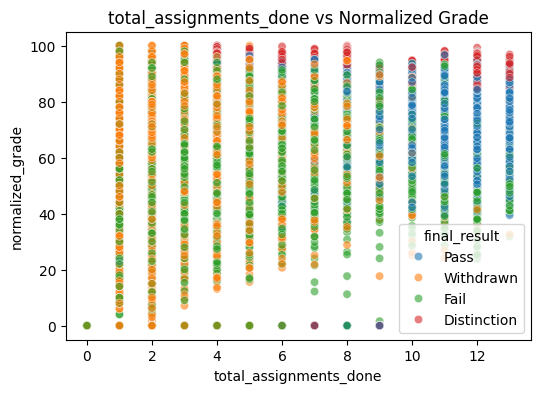

In [77]:
###Scatter plots for all numerical  columns against normalized grades
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in numerical_cols:
    if col != "normalized_grade":
        plt.figure(figsize=(6,4))
        sns.scatterplot(
            data=df,
            x=col,
            y="normalized_grade",
            hue="final_result",
            alpha=0.6
        )
        plt.title(f"{col} vs Normalized Grade")
        plt.show()

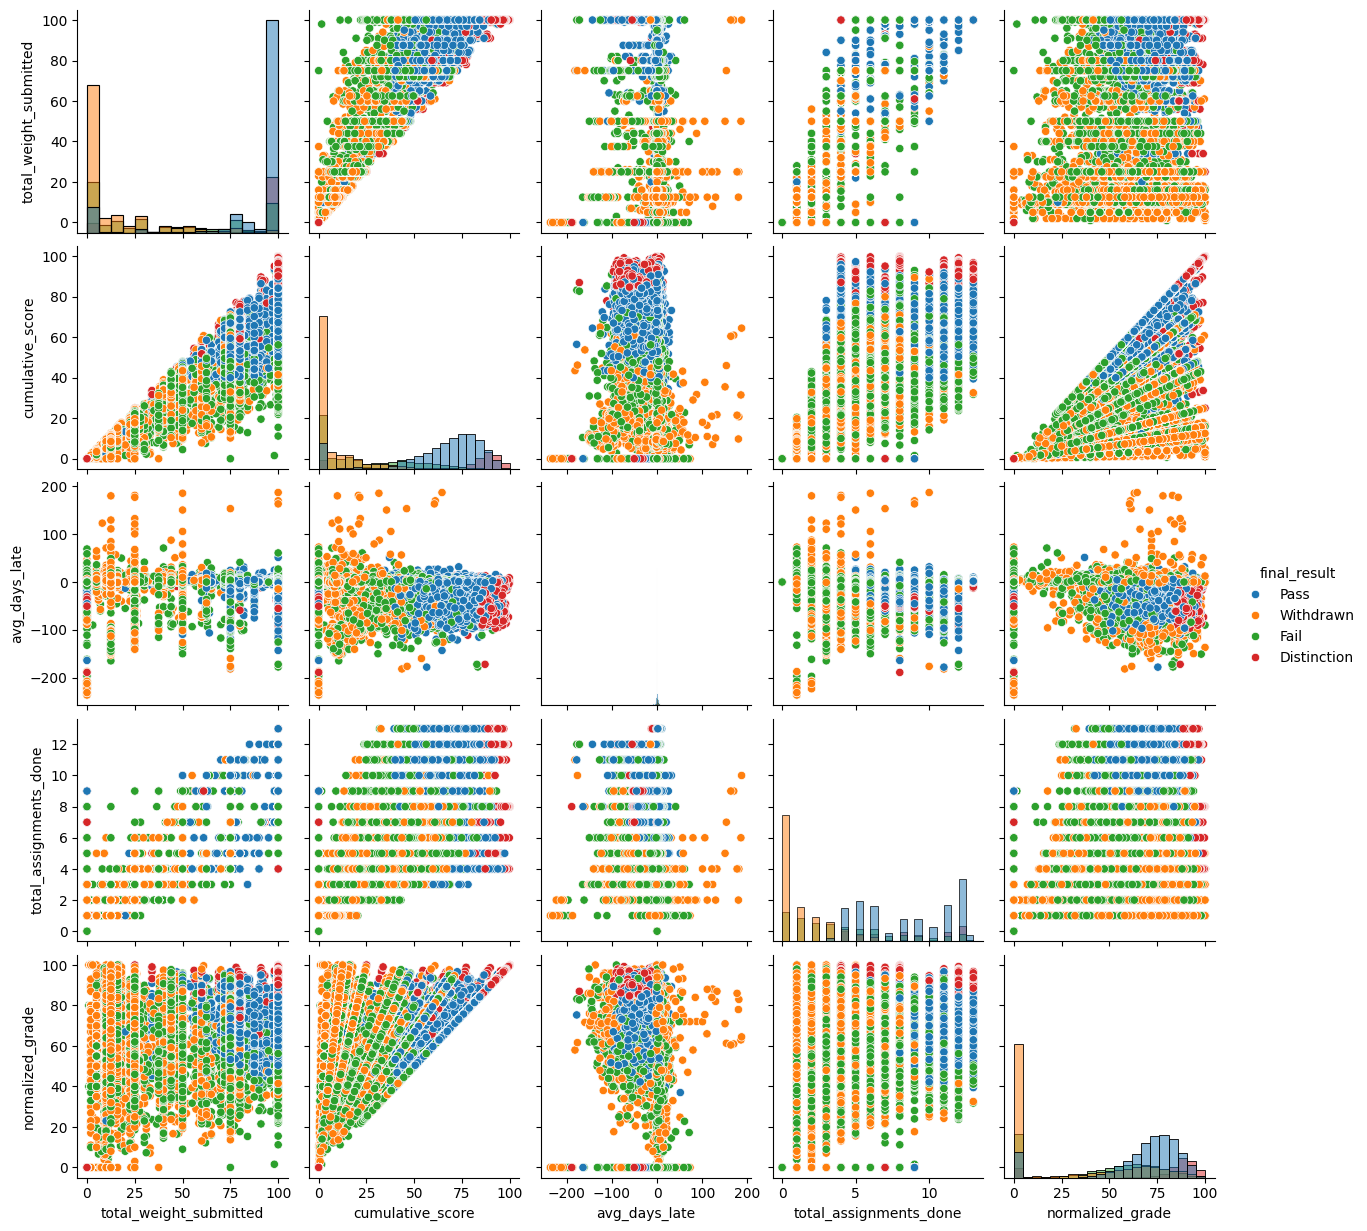

In [78]:
###Pairplots
selected_cols = [
    "total_weight_submitted",
    "cumulative_score",
    "avg_days_late",
    "total_assignments_done",
    "normalized_grade",
    "final_result"
]

sns.pairplot(
    df[selected_cols],
    hue="final_result",
    diag_kind="hist"
)

plt.show()

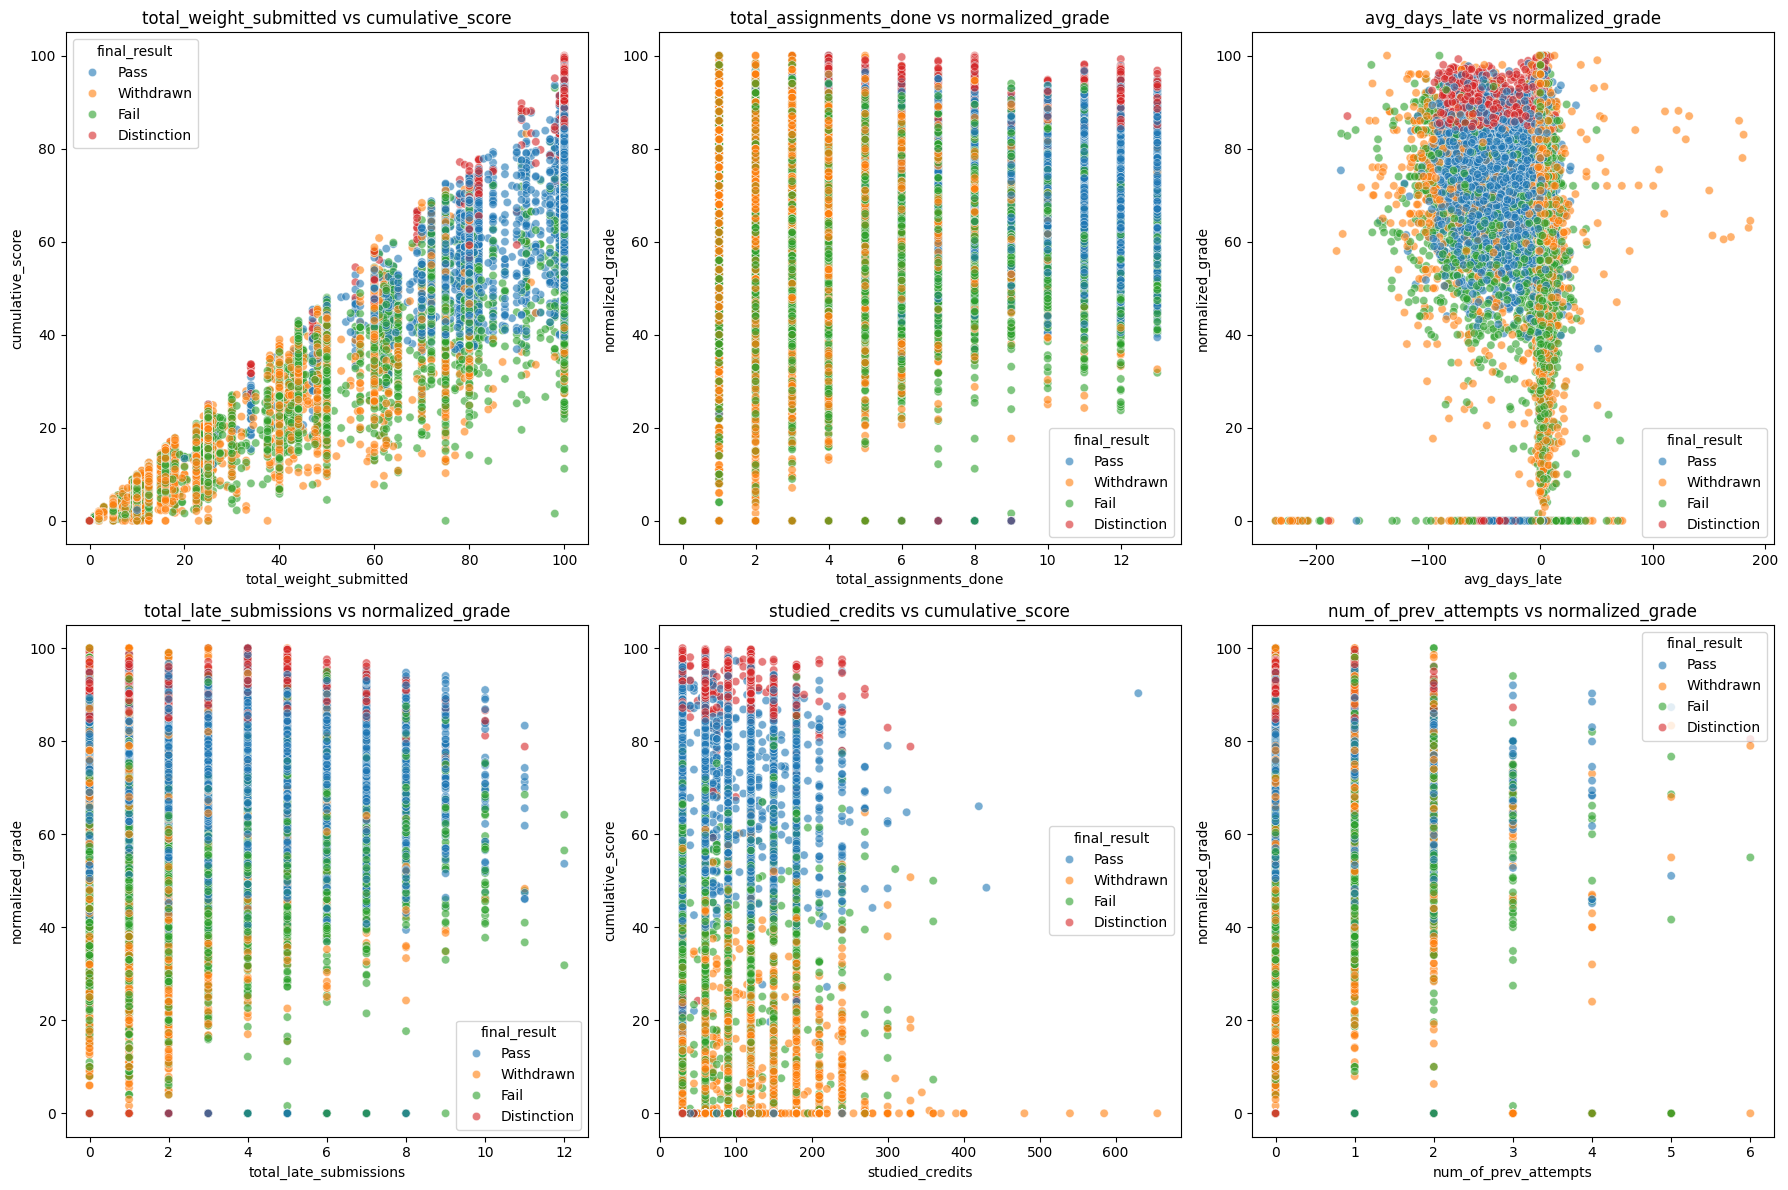

In [79]:
###scatter plots for selected important feature pairs
scatter_pairs = [
    ("total_weight_submitted", "cumulative_score"),
    ("total_assignments_done", "normalized_grade"),
    ("avg_days_late", "normalized_grade"),
    ("total_late_submissions", "normalized_grade"),
    ("studied_credits", "cumulative_score"),
    ("num_of_prev_attempts", "normalized_grade")
]

plt.figure(figsize=(18, 12))

for i, (x, y) in enumerate(scatter_pairs, 1):
    plt.subplot(2, 3, i)
    sns.scatterplot(data=df, x=x, y=y, hue="final_result", alpha=0.6)
    plt.title(f"{x} vs {y}")

plt.tight_layout()
plt.show()

In [ ]:
### EDA observations
###i will prepare EDA observations based on 25% Early student dropoutrisk prediction